In [2]:
import sys
sys.path.append("/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST")
from vae_model import VAE, vae_loss
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch
from torchvision.utils import make_grid
import matplotlib.pyplot as plt

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 128
epochs = 100
patience = 10  
best_loss = float('inf')
patience_counter = 0

transform = transforms.ToTensor()
train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

latent_dim = 20
model = VAE(latent_dim=latent_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(epochs):
    model.train()
    total_loss = 0
    for x, _ in train_loader:
        x = x.to(device)
        optimizer.zero_grad()
        x_recon, mu, logvar = model(x)
        loss = vae_loss(x_recon, x, mu, logvar)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader.dataset)
    print(f"Epoch {epoch + 1}, Loss: {avg_loss:.4f}")

    # Early stopping check
    if avg_loss < best_loss - 1e-4:  
        best_loss = avg_loss
        patience_counter = 0
    else:
        patience_counter += 1
        print(f"  No improvement, patience {patience_counter}/{patience}")
        if patience_counter >= patience:
            print("Early stopping triggered.")
            break


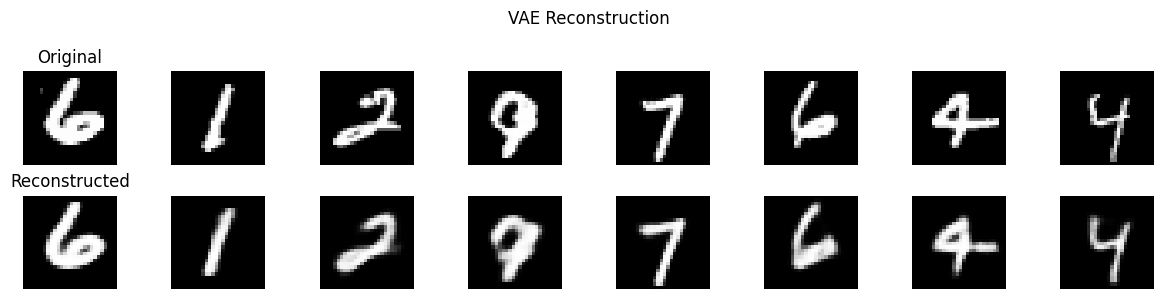

In [4]:
model.eval() 
transform = transforms.ToTensor()
test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=True)

x, _ = next(iter(test_loader))
x = x.to(device)
with torch.no_grad():
    x_recon, _, _ = model(x)

x = x.cpu()
x_recon = x_recon.view(-1, 1, 28, 28).cpu()

fig, axes = plt.subplots(2, 8, figsize=(12, 3))
for i in range(8):
    axes[0, i].imshow(x[i].squeeze(), cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(x_recon[i].squeeze(), cmap='gray')
    axes[1, i].axis('off')

axes[0, 0].set_title("Original")
axes[1, 0].set_title("Reconstructed")
plt.suptitle("VAE Reconstruction")
plt.tight_layout()
plt.show()


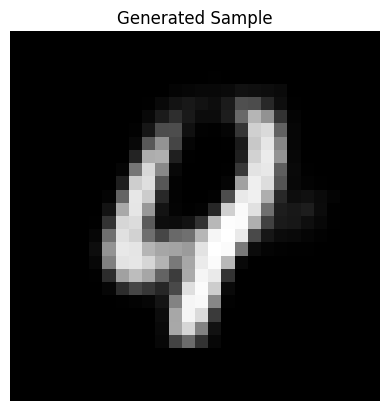

In [14]:
model.eval()
latent_dim = model.latent_dim  

z = torch.randn(1, latent_dim).to(device)

with torch.no_grad():
    x_gen = model.decoder(z).view(1, 1, 28, 28).cpu()

plt.imshow(x_gen[0, 0], cmap='gray')
plt.title("Generated Sample")
plt.axis("off")
plt.show()

In [26]:
from torch.utils.data import Subset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 128
epochs = 100
patience = 10  
best_loss = float('inf')
patience_counter = 0

transform = transforms.ToTensor()
full_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)

# Use only the first 10,000 samples
train_dataset = Subset(full_dataset, range(10000))
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

latent_dim = 20
model = VAE(latent_dim=latent_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(epochs):
    model.train()
    total_loss = 0
    for x, _ in train_loader:
        x = x.to(device)
        optimizer.zero_grad()
        x_recon, mu, logvar = model(x)
        loss = vae_loss(x_recon, x, mu, logvar)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader.dataset)
    print(f"Epoch {epoch + 1}, Loss: {avg_loss:.4f}")

    # Early stopping check
    if avg_loss < best_loss - 1e-4:  
        best_loss = avg_loss
        patience_counter = 0
    else:
        patience_counter += 1
        print(f"  No improvement, patience {patience_counter}/{patience}")
        if patience_counter >= patience:
            print("Early stopping triggered.")
            break


Epoch 1, Loss: 245.8726
Epoch 2, Loss: 176.7053
Epoch 3, Loss: 153.5832
Epoch 4, Loss: 142.5994
Epoch 5, Loss: 134.7361
Epoch 6, Loss: 129.4968
Epoch 7, Loss: 125.7435
Epoch 8, Loss: 122.8110
Epoch 9, Loss: 120.3738
Epoch 10, Loss: 118.5715
Epoch 11, Loss: 117.0311
Epoch 12, Loss: 115.8844
Epoch 13, Loss: 114.8752
Epoch 14, Loss: 113.9137
Epoch 15, Loss: 113.2333
Epoch 16, Loss: 112.7171
Epoch 17, Loss: 111.9027
Epoch 18, Loss: 111.2794
Epoch 19, Loss: 110.8216
Epoch 20, Loss: 110.3332
Epoch 21, Loss: 110.0510
Epoch 22, Loss: 109.6454
Epoch 23, Loss: 109.2273
Epoch 24, Loss: 108.9479
Epoch 25, Loss: 108.5810
Epoch 26, Loss: 108.2380
Epoch 27, Loss: 107.9956
Epoch 28, Loss: 107.8333
Epoch 29, Loss: 107.6665
Epoch 30, Loss: 107.3862
Epoch 31, Loss: 107.0684
Epoch 32, Loss: 106.8885
Epoch 33, Loss: 106.8293
Epoch 34, Loss: 106.5570
Epoch 35, Loss: 106.4162
Epoch 36, Loss: 106.2893
Epoch 37, Loss: 106.1232
Epoch 38, Loss: 105.8920
Epoch 39, Loss: 105.7018
Epoch 40, Loss: 105.6831
Epoch 41,

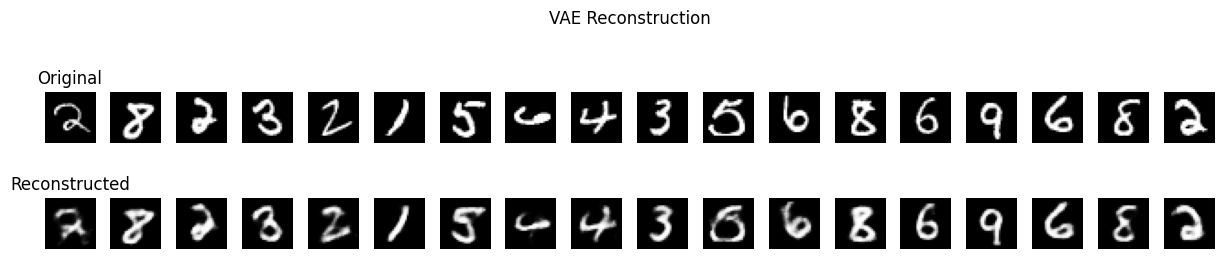

In [21]:
model.eval() 
transform = transforms.ToTensor()
test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=18, shuffle=True)

x, _ = next(iter(test_loader))
x = x.to(device)
with torch.no_grad():
    x_recon, _, _ = model(x)

x = x.cpu()
x_recon = x_recon.view(-1, 1, 28, 28).cpu()

fig, axes = plt.subplots(2, 18, figsize=(12, 3))
for i in range(18):
    axes[0, i].imshow(x[i].squeeze(), cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(x_recon[i].squeeze(), cmap='gray')
    axes[1, i].axis('off')

axes[0, 0].set_title("Original")
axes[1, 0].set_title("Reconstructed")
plt.suptitle("VAE Reconstruction")
plt.tight_layout()
plt.show()


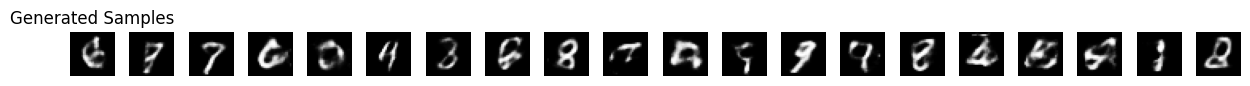

In [27]:
model.eval()
latent_dim = model.latent_dim  
# generate latent vector k latent vector z
k = 20  # Number of latent vectors to generate 
z = torch.randn(k, latent_dim).to(device)
with torch.no_grad():
    x_gen = model.decoder(z).view(k, 1, 28, 28).cpu()   
plt.figure(figsize=(12, 3))
for i in range(k):
    plt.subplot(2, k, i + 1)
    plt.imshow(x_gen[i, 0], cmap='gray')
    plt.axis('off')
    if i == 0:
        plt.title("Generated Samples")
plt.tight_layout()
plt.show()

# CVAE

In [1]:
import sys
sys.path.append("/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST")
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn.functional as F
from cvae_model import CVAE, cvae_loss
from torch.utils.data import Subset
import matplotlib.pyplot as plt

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Hyperparameters
latent_dim = 20
label_dim = 10
batch_size = 128
epochs = 100
lr = 1e-3
sample_size = 60000
# Load MNIST
transform = transforms.ToTensor()
full_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
train_dataset = Subset(full_dataset, range(sample_size))
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Initialize model
model = CVAE(latent_dim=latent_dim, label_dim=label_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

# One-hot encoding helper
def one_hot(labels, num_classes=10):
    return F.one_hot(labels, num_classes).float()

# Training loop
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for x, y in train_loader:
        x = x.view(-1, 784).to(device)
        y = one_hot(y).to(device)

        optimizer.zero_grad()
        recon_x, mu, logvar = model(x, y)
        loss = cvae_loss(recon_x, x, mu, logvar)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader.dataset)
    print(f"Epoch {epoch + 1}, Loss: {avg_loss:.4f}")


Epoch 1, Loss: 163.2422
Epoch 2, Loss: 119.5720
Epoch 3, Loss: 112.2415
Epoch 4, Loss: 109.0227
Epoch 5, Loss: 107.0405
Epoch 6, Loss: 105.7091
Epoch 7, Loss: 104.6756
Epoch 8, Loss: 103.8744
Epoch 9, Loss: 103.1939
Epoch 10, Loss: 102.6034
Epoch 11, Loss: 102.1714
Epoch 12, Loss: 101.7749
Epoch 13, Loss: 101.4149
Epoch 14, Loss: 101.0850
Epoch 15, Loss: 100.7877
Epoch 16, Loss: 100.5389
Epoch 17, Loss: 100.2835
Epoch 18, Loss: 100.1052
Epoch 19, Loss: 99.9348
Epoch 20, Loss: 99.7205
Epoch 21, Loss: 99.5608
Epoch 22, Loss: 99.4278
Epoch 23, Loss: 99.2626
Epoch 24, Loss: 99.1308
Epoch 25, Loss: 98.9716
Epoch 26, Loss: 98.8965
Epoch 27, Loss: 98.7685
Epoch 28, Loss: 98.6700
Epoch 29, Loss: 98.5780
Epoch 30, Loss: 98.4454
Epoch 31, Loss: 98.3525
Epoch 32, Loss: 98.2787
Epoch 33, Loss: 98.1769
Epoch 34, Loss: 98.0963
Epoch 35, Loss: 97.9871
Epoch 36, Loss: 97.9558
Epoch 37, Loss: 97.9222
Epoch 38, Loss: 97.7960
Epoch 39, Loss: 97.7064
Epoch 40, Loss: 97.6352
Epoch 41, Loss: 97.5581
Epoch 4

In [2]:
# save the model to model_saved folder
import os
if not os.path.exists("model_saved"):
    os.makedirs("model_saved")
torch.save(model.state_dict(), f"model_saved/cvae_mnist_{sample_size}.pth")
print(f"Model saved to model_saved/cvae_mnist_{sample_size}.pth")

Model saved to model_saved/cvae_mnist_60000.pth


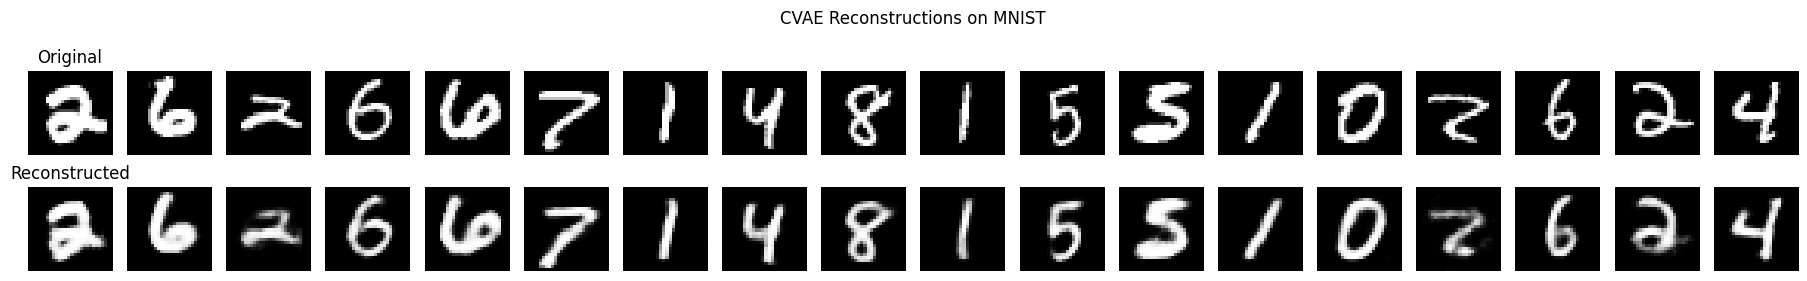

In [14]:
# Set model to evaluation mode
model.eval()

# Prepare test data
transform = transforms.ToTensor()
test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=18, shuffle=True)

# Get a batch
x, y = next(iter(test_loader))
x = x.view(-1, 784).to(device)
y = F.one_hot(y, num_classes=10).float().to(device)

# Reconstruct images
with torch.no_grad():
    x_recon, _, _ = model(x, y)

# Move data to CPU for visualization
x = x.view(-1, 1, 28, 28).cpu()
x_recon = x_recon.view(-1, 1, 28, 28).cpu()

# Plot original and reconstructed images
fig, axes = plt.subplots(2, 18, figsize=(18, 3))
for i in range(18): 
    axes[0, i].imshow(x[i].squeeze(), cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(x_recon[i].squeeze(), cmap='gray')
    axes[1, i].axis('off')

axes[0, 0].set_title("Original")
axes[1, 0].set_title("Reconstructed")
plt.suptitle("CVAE Reconstructions on MNIST")
plt.tight_layout()
plt.show()


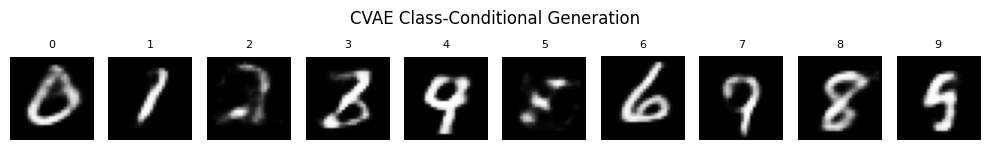

In [15]:
model.eval()

# Generate digits for labels 0 through 9
num_classes = 10
latent_dim = model.latent_dim
device = next(model.parameters()).device  # get model device

with torch.no_grad():
    # Sample one latent vector per class
    z = torch.randn(num_classes, latent_dim).to(device)

    # One-hot encode class labels 0-9
    y = torch.eye(num_classes).to(device)

    # Decode
    generated = model.decode(z, y).view(-1, 1, 28, 28).cpu()

# Plot
fig, axes = plt.subplots(1, num_classes, figsize=(num_classes, 1.5))
for i in range(num_classes):
    axes[i].imshow(generated[i].squeeze(), cmap='gray')
    axes[i].axis('off')
    axes[i].set_title(str(i), fontsize=8)
plt.suptitle("CVAE Class-Conditional Generation", fontsize=12)
plt.tight_layout()
plt.show()


## generate synthetic data

In [4]:
import sys
sys.path.append("/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST")
import torch
from cvae_model import CVAE 
import os
sample_size = 60000
latent_dim = 20
label_dim = 10
model = CVAE(latent_dim=latent_dim, label_dim=label_dim)
os.chdir("/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST")  
#os.chdir("/home/qiyuanliu/")  
model.load_state_dict(torch.load(f"model_saved/cvae_mnist_{sample_size}.pth"))
model.eval()

/tmp/ipykernel_2105858/1863445672.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"model_saved/cvae_mnist_{sample_size}.pth"))


CVAE(
  (fc1): Linear(in_features=794, out_features=400, bias=True)
  (fc_mu): Linear(in_features=400, out_features=20, bias=True)
  (fc_logvar): Linear(in_features=400, out_features=20, bias=True)
  (fc3): Linear(in_features=30, out_features=400, bias=True)
  (fc4): Linear(in_features=400, out_features=784, bias=True)
)

In [ ]:
import torch
import torch.nn.functional as F

model.eval()

n_per_class = 6000
num_classes = 10
total_samples = n_per_class * num_classes
latent_dim = model.latent_dim
device = next(model.parameters()).device

z = torch.randn(total_samples, latent_dim).to(device)
y = torch.arange(num_classes).repeat_interleave(n_per_class)
y_onehot = F.one_hot(y, num_classes=num_classes).float().to(device)

with torch.no_grad():
    gen_imgs = model.decode(z, y_onehot).view(-1, 1, 28, 28).cpu()  # shape: [60000, 1, 28, 28]


In [5]:
import torch
import torch.nn.functional as F

def generate_images_in_batches(model, total_samples, latent_dim, num_classes, batch_size=10000, device='cuda'):
    model.eval()
    generated_images = []
    all_labels = []

    for start in range(0, total_samples, batch_size):
        end = min(start + batch_size, total_samples)
        batch_size_actual = end - start

        # Generate z and y
        z = torch.randn(batch_size_actual, latent_dim).to(device)
        y = torch.arange(num_classes).repeat_interleave(total_samples // num_classes)[start:end]
        y_onehot = F.one_hot(y, num_classes=num_classes).float().to(device)

        with torch.no_grad():
            imgs = model.decode(z, y_onehot).view(-1, 1, 28, 28).cpu()
            generated_images.append(imgs)
            all_labels.append(y)

    images = torch.cat(generated_images, dim=0)
    labels = torch.cat(all_labels, dim=0)
    return images, labels



In [6]:
latent_dim = model.latent_dim
device = next(model.parameters()).device
gen_imgs,y = generate_images_in_batches(
    model=model,
    total_samples=60000,#6000000,
    latent_dim=latent_dim,
    num_classes=10,
    batch_size=10000,
    device=device
)
print("Generated shape:", gen_imgs.shape)  # Should be [6000000, 1, 28, 28]


Generated shape: torch.Size([60000, 1, 28, 28])


In [7]:
os.chdir("/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST")  
save_path = f"data_saved/synthetic_mnist_cvae_{sample_size}.pt"
torch.save({
    'images': gen_imgs,    # Tensor [6000000, 1, 28, 28]
    'labels': y            # Tensor [6000000]
}, save_path)

print(f"Saved to {save_path}")

Saved to data_saved/synthetic_mnist_cvae_60000.pt


/tmp/ipykernel_3246439/1602137459.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load("data_saved/synthetic_mnist_cvae_60000_2.pt")


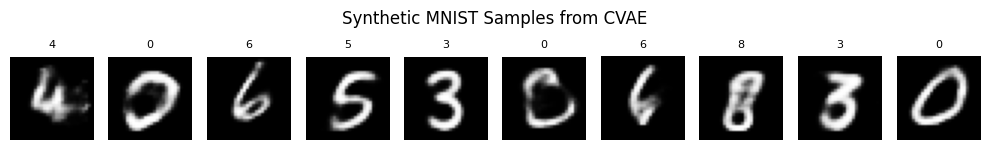

In [8]:
import matplotlib.pyplot as plt
data = torch.load("data_saved/synthetic_mnist_cvae_60000_2.pt")
images = data['images']   # [60000, 1, 28, 28]
labels = data['labels']   # [60000]

num_samples = 10
indices = torch.randperm(len(images))[:num_samples]

fig, axes = plt.subplots(1, num_samples, figsize=(num_samples, 1.5))
for i, idx in enumerate(indices):
    axes[i].imshow(images[idx].squeeze(), cmap='gray')
    axes[i].axis('off')
    axes[i].set_title(str(labels[idx].item()), fontsize=8)
plt.suptitle("Synthetic MNIST Samples from CVAE", fontsize=12)
plt.tight_layout()
plt.show()

## Train the Discriminator

In [8]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, TensorDataset, ConcatDataset

# real MNIST (60,000）
transform = transforms.ToTensor()
mnist = datasets.MNIST('./data', train=True, download=True, transform=transform)
real_imgs = torch.stack([mnist[i][0] for i in range(60000)])  # shape: [60000, 1, 28, 28]
real_labels = torch.ones(60000, 1)  # label = 1

# synthetic data（60,000）
data = torch.load("data_saved/synthetic_mnist_cvae_60000.pt")
fake_imgs = data['images'][:60000]  # shape: [60000, 1, 28, 28]
fake_labels = torch.zeros(60000, 1)  # label = 0

X_all = torch.cat([real_imgs, fake_imgs], dim=0)
y_all = torch.cat([real_labels, fake_labels], dim=0)

perm = torch.randperm(len(X_all))
X_all = X_all[perm]
y_all = y_all[perm]

from torch.utils.data import TensorDataset
disc_dataset = TensorDataset(X_all, y_all)
disc_loader = DataLoader(disc_dataset, batch_size=128, shuffle=True)


/tmp/ipykernel_2105858/2678432030.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load("data_saved/synthetic_mnist_cvae_60000.pt")


In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

from discriminator import Discriminator
from torch import nn
D = Discriminator().to(device)
optimizer = torch.optim.Adam(D.parameters(), lr=1e-3)
loss_fn = nn.BCELoss()

for epoch in range(25):

    D.train()
    total_loss = 0
    correct = 0
    total = 0

    for x_batch, y_batch in disc_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        preds = D(x_batch)
        loss = loss_fn(preds, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        predicted = (preds > 0.5).float()
        correct += (predicted == y_batch).sum().item()
        total += y_batch.size(0)

    acc = correct / total
    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}, Accuracy: {acc*100:.2f}%")


Epoch 1, Loss: 123.4456, Accuracy: 94.42%
Epoch 2, Loss: 41.3151, Accuracy: 98.38%
Epoch 3, Loss: 29.5220, Accuracy: 98.86%
Epoch 4, Loss: 29.1426, Accuracy: 98.87%
Epoch 5, Loss: 21.5987, Accuracy: 99.18%
Epoch 6, Loss: 17.7029, Accuracy: 99.29%
Epoch 7, Loss: 17.7691, Accuracy: 99.32%
Epoch 8, Loss: 12.1858, Accuracy: 99.53%
Epoch 9, Loss: 12.0637, Accuracy: 99.53%
Epoch 10, Loss: 10.9539, Accuracy: 99.57%
Epoch 11, Loss: 9.9800, Accuracy: 99.61%
Epoch 12, Loss: 7.5507, Accuracy: 99.71%
Epoch 13, Loss: 7.7892, Accuracy: 99.70%
Epoch 14, Loss: 6.2344, Accuracy: 99.77%
Epoch 15, Loss: 6.2802, Accuracy: 99.76%
Epoch 16, Loss: 6.7610, Accuracy: 99.73%
Epoch 17, Loss: 6.4297, Accuracy: 99.79%
Epoch 18, Loss: 9.5664, Accuracy: 99.71%
Epoch 19, Loss: 1.7508, Accuracy: 99.95%
Epoch 20, Loss: 3.1649, Accuracy: 99.88%
Epoch 21, Loss: 4.5607, Accuracy: 99.82%
Epoch 22, Loss: 3.5117, Accuracy: 99.87%
Epoch 23, Loss: 4.1007, Accuracy: 99.85%
Epoch 24, Loss: 3.6946, Accuracy: 99.86%
Epoch 25, Loss

In [11]:
save_path = "model_saved/discriminator_mnist_cvae_more_epoch.pth"
torch.save(D.state_dict(), save_path)

## Filter

In [ ]:
import torch
from torch.utils.data import DataLoader
from discriminator import Discriminator
import os
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
D = Discriminator().to(device)
os.chdir("/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST")
D.load_state_dict(torch.load("model_saved/discriminator_mnist_cvae_2.pth"))
D.eval()

data = torch.load("data_saved/synthetic_mnist_cvae_60000.pt")
synthetic_images = data['images']  # [60000, 1, 28, 28]

synthetic_loader = DataLoader(synthetic_images, batch_size=512)

all_probs = []

with torch.no_grad():
    for batch in synthetic_loader:
        batch = batch.to(device)
        probs = D(batch)  # [batch_size, 1], already sigmoid activated
        all_probs.append(probs.cpu())

all_probs = torch.cat(all_probs, dim=0)

print(f"Got probabilities for {all_probs.shape[0]} synthetic samples.")


/tmp/ipykernel_2105858/3627171738.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  D.load_state_dict(torch.load("model_saved/discriminator_mnist_cvae_2.pth"))
/tmp/ipyker

In [10]:
print(data['images'].shape)
print(data['labels'].shape)

torch.Size([6000000, 1, 28, 28])
torch.Size([6000000])


In [22]:
# Flatten probs to shape [N]
probs = all_probs.squeeze(1)

# Load images and labels
images = data['images']      # [N, 1, 28, 28]
labels = data['labels']      # [N]

# Create mask for p > 0.5
mask = probs > 0.4

# Apply mask
filtered_images = images[mask]
filtered_labels = labels[mask]

print(f"Selected {filtered_images.shape[0]} samples with p > 0.4")
# Save to file
torch.save({
    'images': filtered_images,
    'labels': filtered_labels
}, "data_saved/synthetic_mnist_filtered_pgt04_10000.pt")

print("Saved to: data_saved/synthetic_mnist_filtered_pgt04_10000.pt")


Selected 60653 samples with p > 0.4
Saved to: data_saved/synthetic_mnist_filtered_pgt04_10000.pt


In [11]:
filtered_labels.shape

torch.Size([75242])

In [7]:
torch.save(all_probs, "data_saved/synthetic_mnist_cvae_probs_larger.pt")
print("✅ Probabilities saved.")

✅ Probabilities saved.


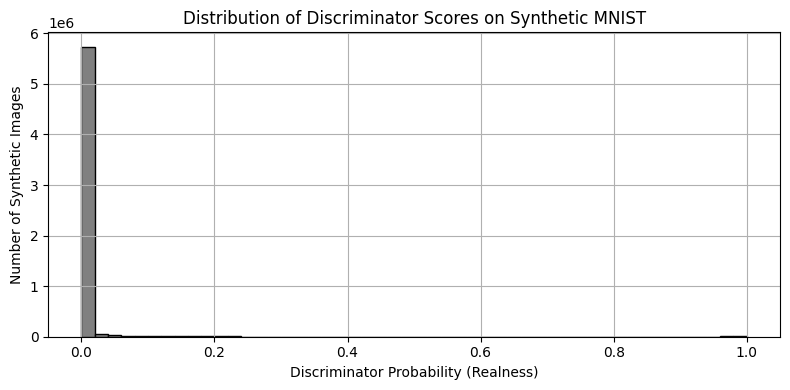

In [9]:
import torch
import matplotlib.pyplot as plt
os.chdir("/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST")
#probs = torch.load("data_saved/synthetic_mnist_cvae_probs_2.pt")  # shape: [60000, 1]
probs = all_probs#probs.squeeze().numpy()  # shape: [60000]
probs = probs.squeeze().numpy()  # shape: [60000]
plt.figure(figsize=(8, 4))
plt.hist(probs, bins=50, color='gray', edgecolor='black')
plt.xlabel("Discriminator Probability (Realness)")
plt.ylabel("Number of Synthetic Images")
plt.title("Distribution of Discriminator Scores on Synthetic MNIST")
plt.grid(True)
plt.tight_layout()
plt.show()


In [23]:
all_probs.max()

tensor(1.0000)

In [11]:
# how many synthetic images have a probability greater than 0.5?
a=0.5
print(f"Number of synthetic images with probability > 0.5: {all_probs[all_probs > a].numel()} out of {all_probs.numel()} total samples.")
print(f"Percentage: {100 * all_probs[all_probs > a].numel() / all_probs.numel():.2f}%")

Number of synthetic images with probability > 0.5: 53380 out of 6000000 total samples.
Percentage: 0.89%


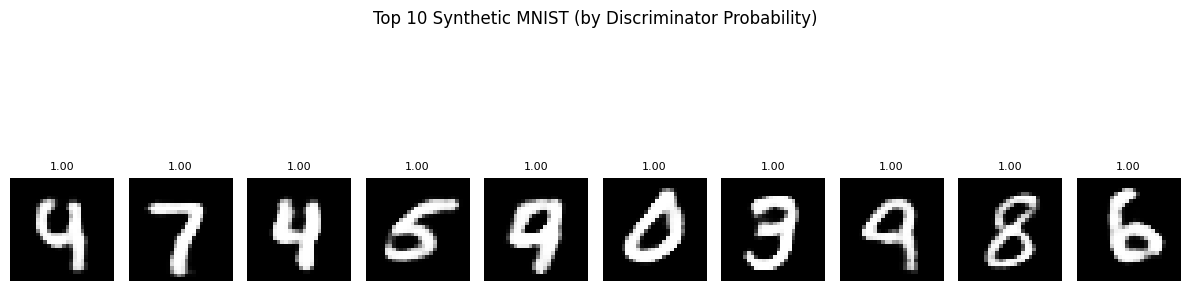

In [13]:
import matplotlib.pyplot as plt

# Get the top 10 indices with highest discriminator probabilities
topk = torch.topk(all_probs.squeeze(), 10)  # topk.values, topk.indices
topk_indices = topk.indices

# Get the corresponding images
top_images = synthetic_images[topk_indices]

# Plot the images
plt.figure(figsize=(12, 4))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(top_images[i].squeeze().numpy(), cmap='gray')
    plt.axis('off')
    plt.title(f"{topk.values[i]:.2f}", fontsize=8)

plt.tight_layout()
plt.suptitle("Top 10 Synthetic MNIST (by Discriminator Probability)", y=1.05)
plt.show()


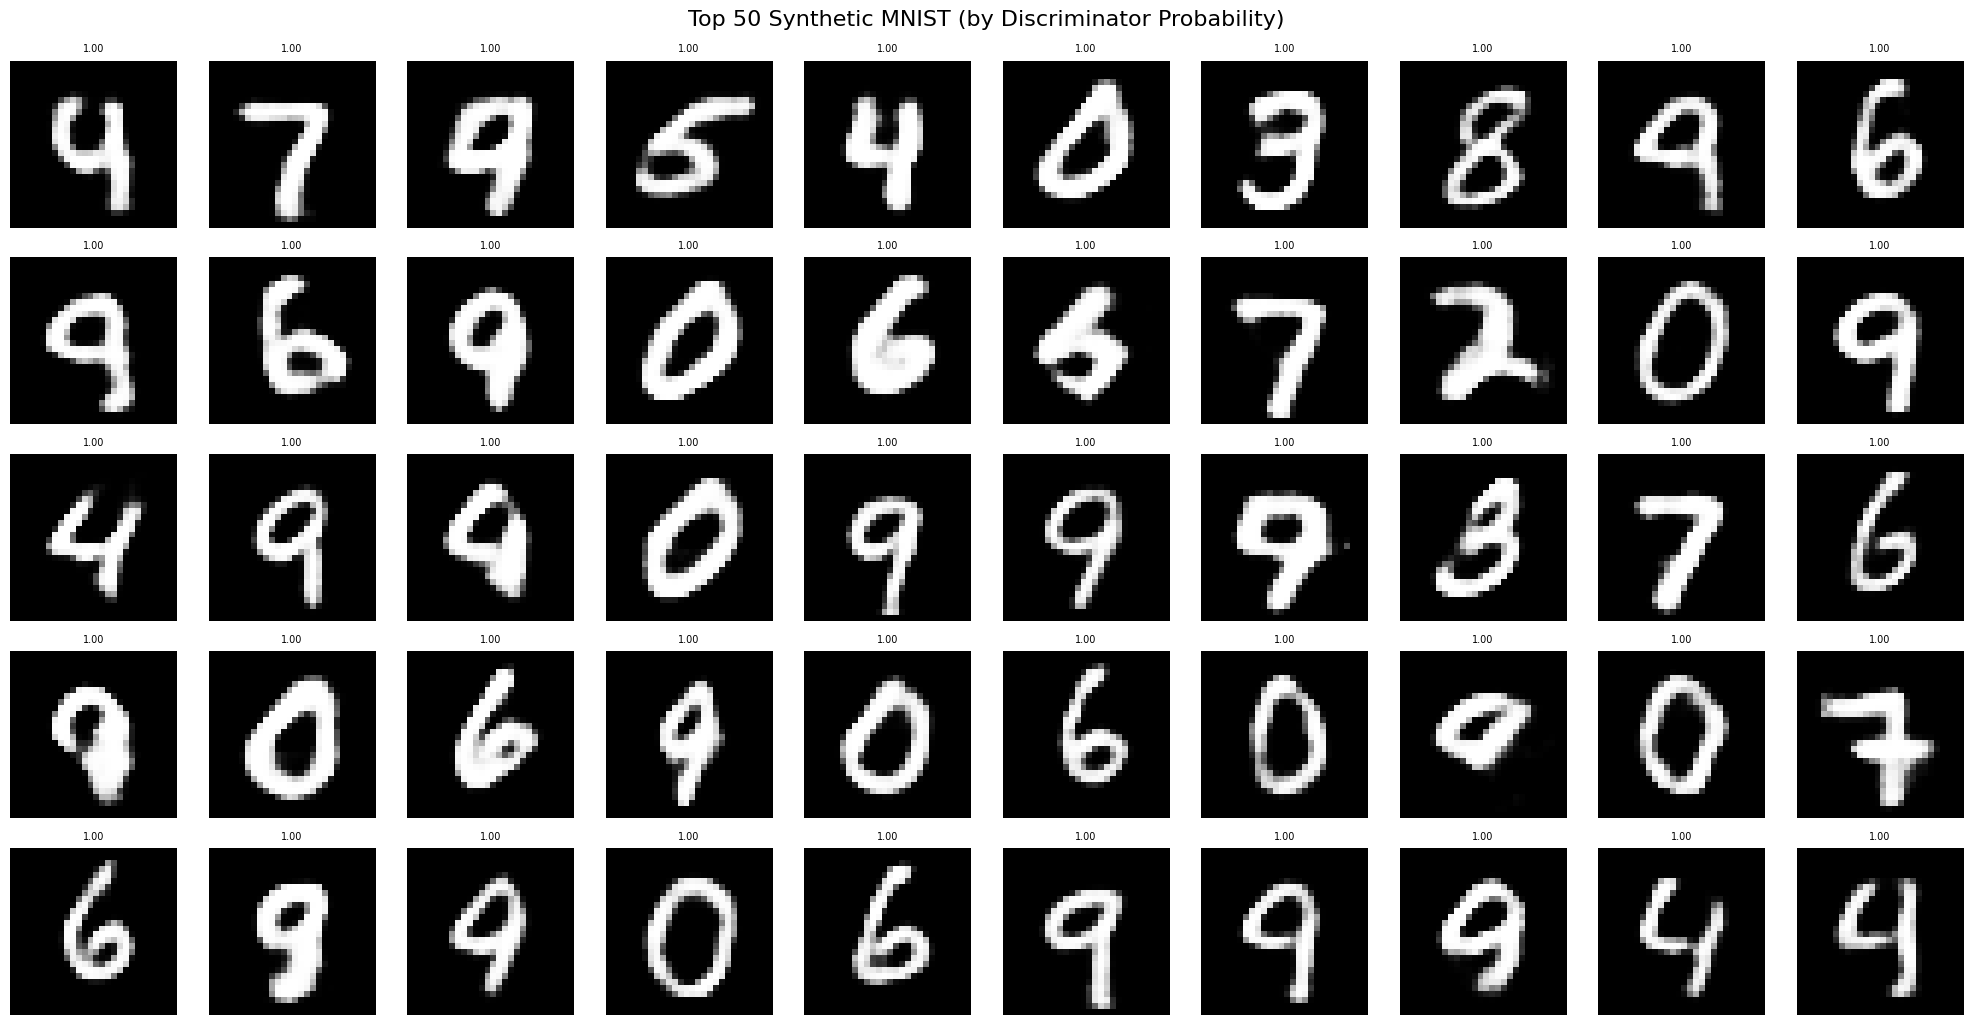

In [14]:
import matplotlib.pyplot as plt

# Get the top 50 indices with highest discriminator probabilities
topk = torch.topk(all_probs.squeeze(), 50)
topk_indices = topk.indices
top_images = synthetic_images[topk_indices]

# Plot in a 5x10 grid
plt.figure(figsize=(20, 10))
for i in range(50):
    plt.subplot(5, 10, i + 1)
    plt.imshow(top_images[i].squeeze().numpy(), cmap='gray')
    plt.axis('off')
    plt.title(f"{topk.values[i]:.2f}", fontsize=7)

plt.tight_layout()
plt.suptitle("Top 50 Synthetic MNIST (by Discriminator Probability)", y=1.02, fontsize=16)
plt.show()


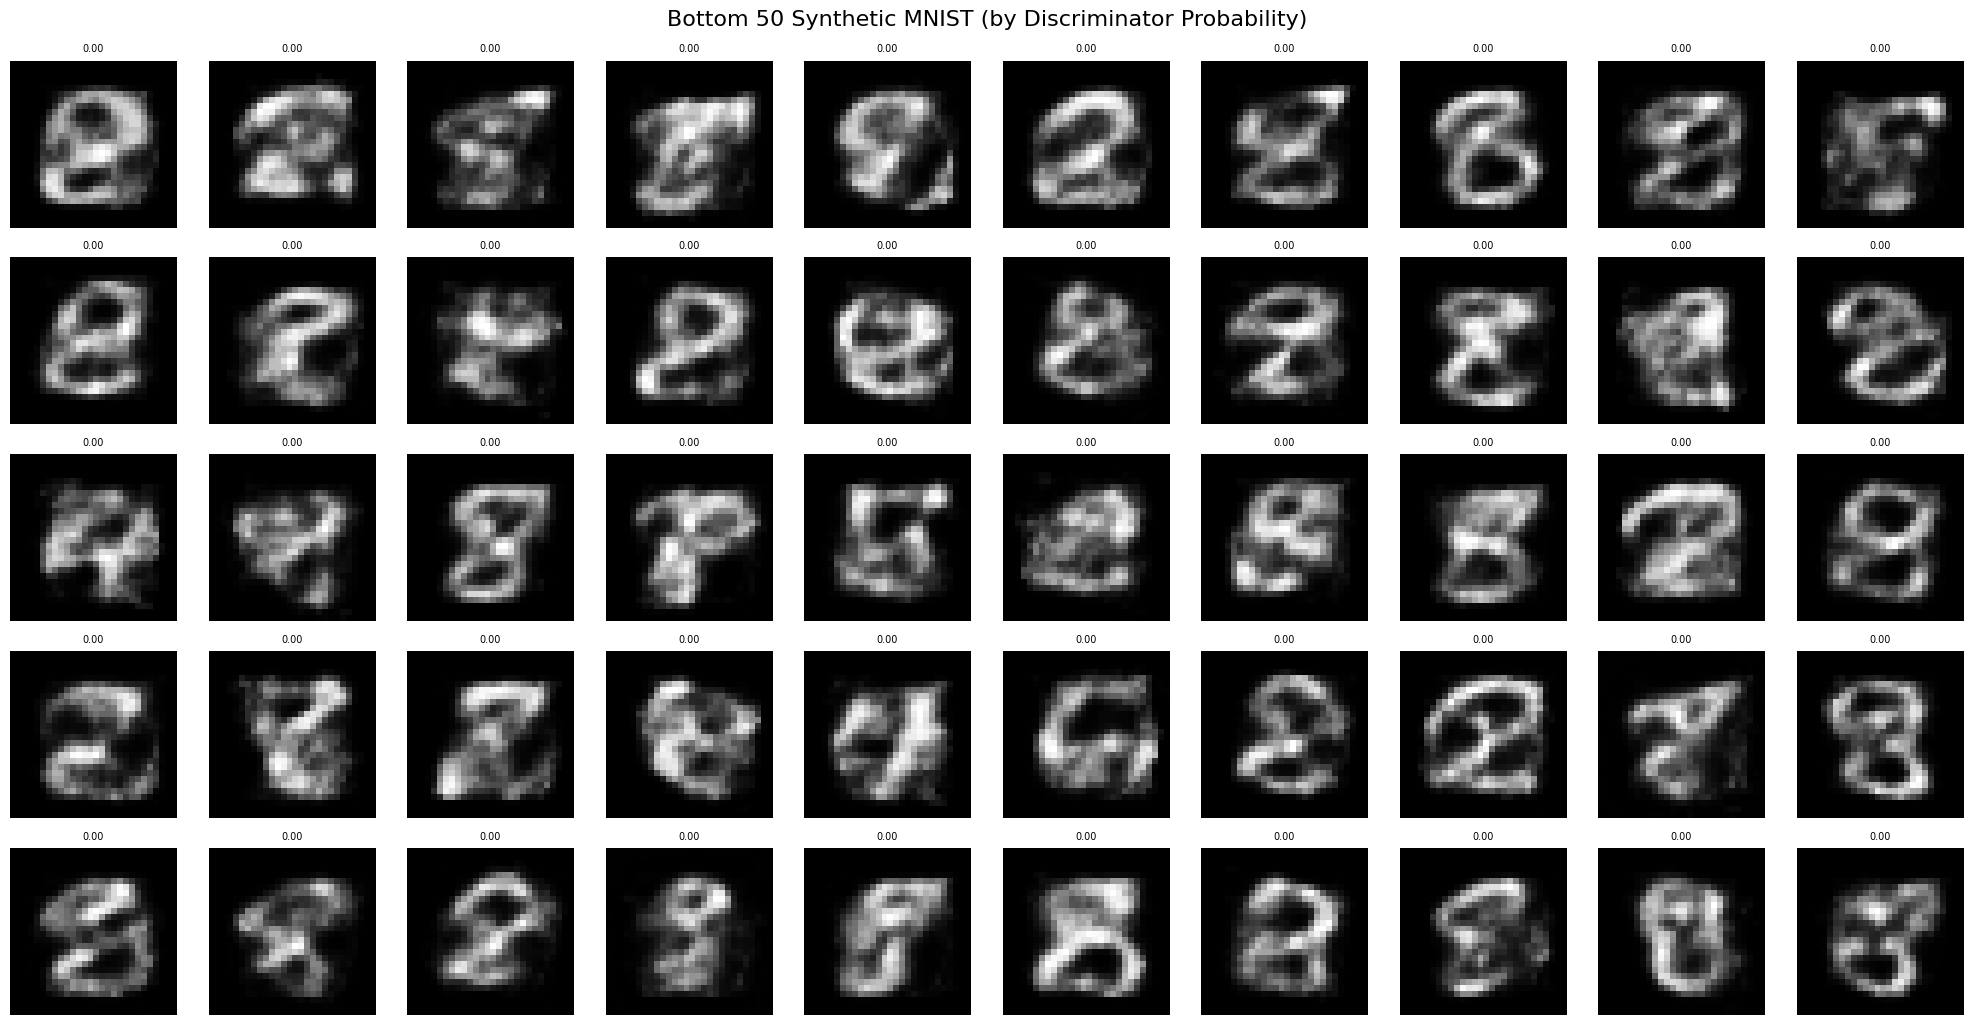

In [15]:
import matplotlib.pyplot as plt

# Get the bottom 50 indices with lowest discriminator probabilities
bottomk = torch.topk(all_probs.squeeze(), 50, largest=False)
bottomk_indices = bottomk.indices
bottom_images = synthetic_images[bottomk_indices]

# Plot in a 5x10 grid
plt.figure(figsize=(20, 10))
for i in range(50):
    plt.subplot(5, 10, i + 1)
    plt.imshow(bottom_images[i].squeeze().numpy(), cmap='gray')
    plt.axis('off')
    plt.title(f"{bottomk.values[i]:.2f}", fontsize=7)

plt.tight_layout()
plt.suptitle("Bottom 50 Synthetic MNIST (by Discriminator Probability)", y=1.02, fontsize=16)
plt.show()


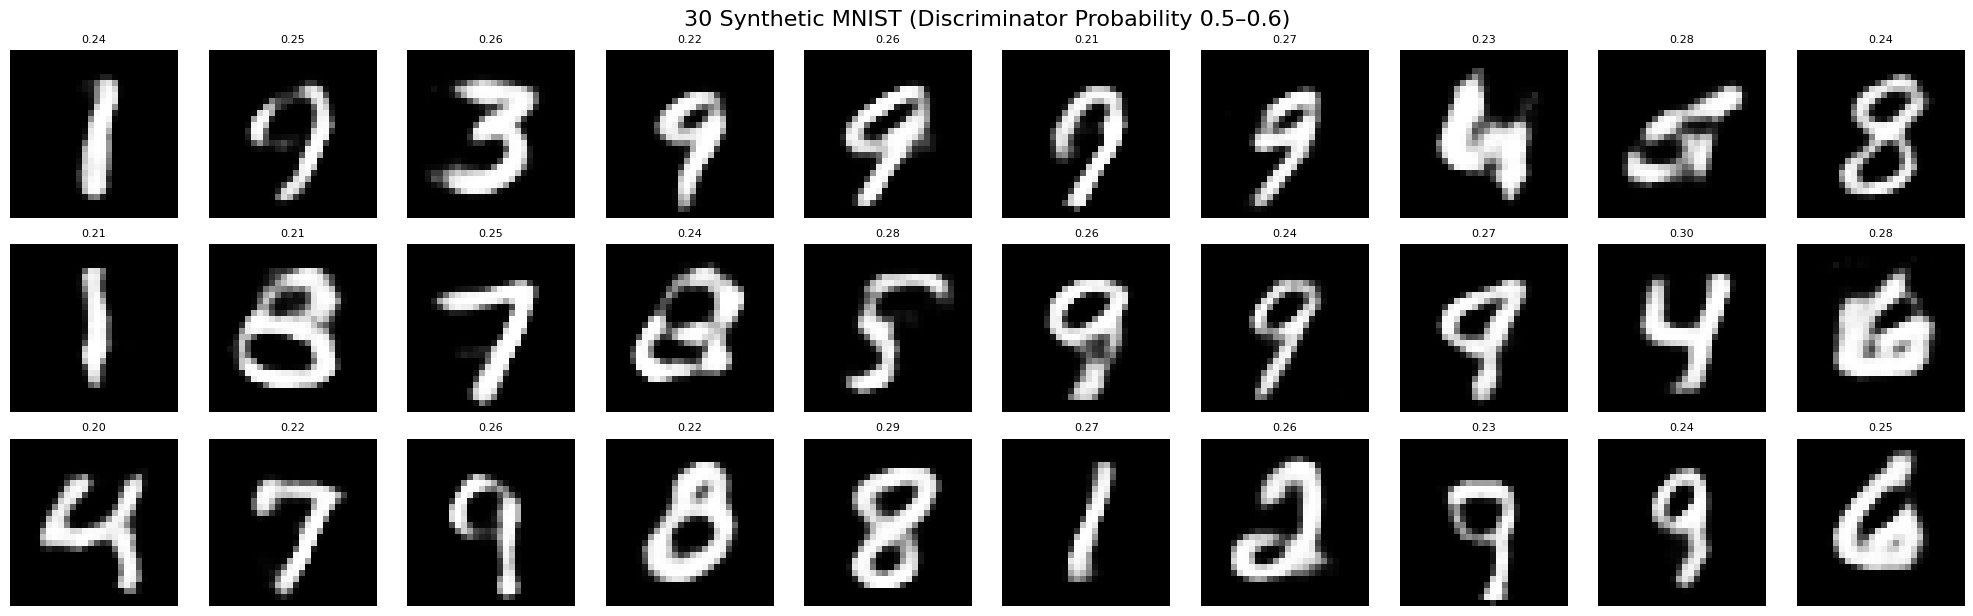

In [16]:
import matplotlib.pyplot as plt

# Step 1: Create mask for probabilities between 0.5 and 0.6
mask = (all_probs.squeeze() >= 0.2) & (all_probs.squeeze() <= 0.3)
indices_in_range = torch.nonzero(mask).squeeze()

# Step 2: Select 30 (randomly if more than 30 available)
if indices_in_range.numel() > 30:
    selected_indices = indices_in_range[torch.randperm(len(indices_in_range))[:30]]
else:
    selected_indices = indices_in_range

# Step 3: Get the images and their probabilities
selected_images = synthetic_images[selected_indices]
selected_probs = all_probs[selected_indices]

# Step 4: Plot in 3x10 grid
plt.figure(figsize=(20, 6))
for i in range(len(selected_images)):
    plt.subplot(3, 10, i + 1)
    plt.imshow(selected_images[i].squeeze().numpy(), cmap='gray')
    plt.axis('off')
    plt.title(f"{selected_probs[i].item():.2f}", fontsize=8)

plt.tight_layout()
plt.suptitle("30 Synthetic MNIST (Discriminator Probability 0.5–0.6)", y=1.02, fontsize=16)
plt.show()


Total samples with prob > 0.5: 53380
Digit 0: 9841 samples, ratio = 0.184
Digit 1: 7741 samples, ratio = 0.145
Digit 2: 2526 samples, ratio = 0.047
Digit 3: 4427 samples, ratio = 0.083
Digit 4: 3438 samples, ratio = 0.064
Digit 5: 1877 samples, ratio = 0.035
Digit 6: 6714 samples, ratio = 0.126
Digit 7: 4758 samples, ratio = 0.089
Digit 8: 2076 samples, ratio = 0.039
Digit 9: 9982 samples, ratio = 0.187


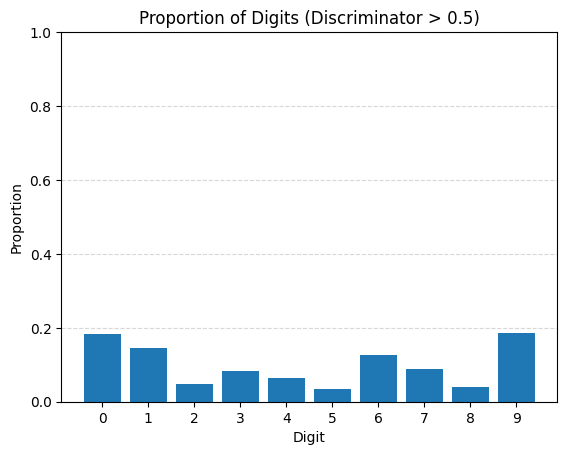

In [17]:
import torch
import matplotlib.pyplot as plt

# Step 1: Flatten the probabilities tensor
probs = all_probs.squeeze()  # shape: [60000]

# Step 2: Create mask for discriminator > 0.5
mask = probs > 0.5

# Step 3: Get corresponding labels for filtered samples
filtered_labels = labels[mask]  # shape: [N_filtered]

# Step 4: Count number of each digit (0–9)
counts = torch.bincount(filtered_labels, minlength=10)
total = counts.sum()
ratios = counts.float() / total

# Step 5: Print result
print(f"Total samples with prob > 0.5: {total.item()}")
for i in range(10):
    print(f"Digit {i}: {counts[i].item()} samples, ratio = {ratios[i]:.3f}")

# Step 6: Optional bar plot
plt.bar(range(10), ratios.numpy())
plt.xlabel("Digit")
plt.ylabel("Proportion")
plt.title("Proportion of Digits (Discriminator > 0.5)")
plt.xticks(range(10))
plt.ylim(0, 1)
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.show()


# Train the CVAE on the filered synthetic data

In [23]:
import sys
sys.path.append("/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST")

import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn.functional as F
from cvae_model import CVAE, cvae_loss
import matplotlib.pyplot as plt

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Hyperparameters
latent_dim = 20
label_dim = 10
batch_size = 128
epochs = 100
lr = 1e-3

# Load filtered synthetic data
data = torch.load("data_saved/synthetic_mnist_filtered_pgt04_10000.pt")
images = data["images"]  # shape: [N, 1, 28, 28]
labels = data["labels"]  # shape: [N]

print(f"Loaded {images.shape[0]} filtered synthetic samples")

# Preprocess: flatten images and convert labels to one-hot
images = images.view(-1, 784)  # flatten to [N, 784]
labels_onehot = F.one_hot(labels, num_classes=label_dim).float()

# Create dataset and dataloader
dataset = TensorDataset(images, labels_onehot)
train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# Initialize model
model = CVAE(latent_dim=latent_dim, label_dim=label_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

# Training loop
for epoch in range(epochs):
    model.train()
    total_loss = 0

    for x, y in train_loader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        recon_x, mu, logvar = model(x, y)
        loss = cvae_loss(recon_x, x, mu, logvar)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader.dataset)
    print(f"Epoch {epoch + 1}, Loss: {avg_loss:.4f}")


/tmp/ipykernel_3246439/3679685349.py:21: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load("data_saved/synthetic_mnist_filtered_pgt04_10000.pt")


Loaded 60653 filtered synthetic samples
Epoch 1, Loss: 139.9889
Epoch 2, Loss: 102.2966
Epoch 3, Loss: 96.3532
Epoch 4, Loss: 93.8196
Epoch 5, Loss: 92.3090
Epoch 6, Loss: 91.3148
Epoch 7, Loss: 90.5695
Epoch 8, Loss: 90.0619
Epoch 9, Loss: 89.6309
Epoch 10, Loss: 89.3277
Epoch 11, Loss: 89.0244
Epoch 12, Loss: 88.8214
Epoch 13, Loss: 88.6438
Epoch 14, Loss: 88.5343
Epoch 15, Loss: 88.3613
Epoch 16, Loss: 88.2502
Epoch 17, Loss: 88.1360
Epoch 18, Loss: 88.0576
Epoch 19, Loss: 87.9837
Epoch 20, Loss: 87.8808
Epoch 21, Loss: 87.8480
Epoch 22, Loss: 87.7559
Epoch 23, Loss: 87.7239
Epoch 24, Loss: 87.6419
Epoch 25, Loss: 87.6312
Epoch 26, Loss: 87.5409
Epoch 27, Loss: 87.4778
Epoch 28, Loss: 87.4381
Epoch 29, Loss: 87.4256
Epoch 30, Loss: 87.3447
Epoch 31, Loss: 87.3385
Epoch 32, Loss: 87.3128
Epoch 33, Loss: 87.2906
Epoch 34, Loss: 87.2434
Epoch 35, Loss: 87.2259
Epoch 36, Loss: 87.1798
Epoch 37, Loss: 87.1636
Epoch 38, Loss: 87.1582
Epoch 39, Loss: 87.1236
Epoch 40, Loss: 87.0897
Epoch 4

In [24]:
# save the model to model_saved folder
import os
os.chdir("/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST")
torch.save(model.state_dict(), f"model_saved/cvae_mnist_filtered_synthetic_data_10000.pth")
print(f"Model saved to model_saved/cvae_mnist_filtered_synthetic_data_10000.pth")

Model saved to model_saved/cvae_mnist_filtered_synthetic_data_10000.pth


In [25]:
# use the new model to generate 60000 samples
import sys
sys.path.append("/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST")
import torch
from cvae_model import CVAE 
import os

latent_dim = 20
label_dim = 10
model = CVAE(latent_dim=latent_dim, label_dim=label_dim)
#os.chdir("/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST")  
os.chdir("/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST")
model.load_state_dict(torch.load("model_saved/cvae_mnist_filtered_synthetic_data_10000.pth"))
model.eval()


import torch
import torch.nn.functional as F

model.eval()

n_per_class = 60000
num_classes = 10
total_samples = n_per_class * num_classes
latent_dim = model.latent_dim
device = next(model.parameters()).device

z = torch.randn(total_samples, latent_dim).to(device)
y = torch.arange(num_classes).repeat_interleave(n_per_class)
y_onehot = F.one_hot(y, num_classes=num_classes).float().to(device)

with torch.no_grad():
    gen_imgs = model.decode(z, y_onehot).view(-1, 1, 28, 28).cpu()  # shape: [60000, 1, 28, 28]


/tmp/ipykernel_3246439/1433912921.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("model_saved/cvae_mnist_filtered_synthetic_data_10000

In [26]:
# save the generated images and labels
import torch
os.chdir("/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST")
save_path = "data_saved/synthetic_mnist_cvae_filtered_synthetic_model_generated_data_10000.pt"
torch.save({"images": gen_imgs, "labels": y}, save_path)
print(f"Generated images and labels saved to {save_path}")


Generated images and labels saved to data_saved/synthetic_mnist_cvae_filtered_synthetic_model_generated_data_10000.pt


# FID

In [31]:
from torchvision.datasets import MNIST
from torchvision import transforms
from torch.utils.data import TensorDataset
import os
import sys
import torch
sys.path.append("/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST")

from FID import calculate_fid_score

transform = transforms.ToTensor()

# Real MNIST
real_ds = MNIST(root='./data', train=False, download=True, transform=transform)
os.chdir("/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST")
# Synthetic dataset
synthetic = torch.load("data_saved/synthetic_mnist_cvae_10000_2.pt")
synthetic_ds = TensorDataset(synthetic['images'], torch.zeros(len(synthetic['images'])))

# FID computation
fid_value = calculate_fid_score(real_ds, synthetic_ds)
print(f"FID Score: {fid_value:.2f}")

/tmp/ipykernel_3246439/2991570029.py:17: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  synthetic = torch.load("data_saved/synthetic_mnist_cvae_10000_2.pt")
Extracting featur

FID Score: 0.04


In [32]:
from torchvision.datasets import MNIST
from torchvision import transforms
from torch.utils.data import TensorDataset
import os
import sys
import torch
sys.path.append("/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST")

from FID import calculate_fid_score

transform = transforms.ToTensor()

# Real MNIST
real_ds = MNIST(root='./data', train=False, download=True, transform=transform)
os.chdir("/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST")
# Synthetic dataset
synthetic = torch.load("data_saved/synthetic_mnist_filtered_pgt04_10000.pt")
synthetic_ds = TensorDataset(synthetic['images'], torch.zeros(len(synthetic['images'])))

# FID computation
fid_value = calculate_fid_score(real_ds, synthetic_ds)
print(f"FID Score: {fid_value:.2f}")

/tmp/ipykernel_3246439/1274000176.py:17: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  synthetic = torch.load("data_saved/synthetic_mnist_filtered_pgt04_10000.pt")
Extractin

FID Score: 0.03


In [33]:
from torchvision.datasets import MNIST
from torchvision import transforms
from torch.utils.data import TensorDataset
import os
import sys
import torch
sys.path.append("/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST")

from FID import calculate_fid_score

transform = transforms.ToTensor()

# Real MNIST
real_ds = MNIST(root='./data', train=False, download=True, transform=transform)
os.chdir("/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST")
# Synthetic dataset
synthetic = torch.load("data_saved/synthetic_mnist_cvae_filtered_synthetic_model_generated_data_10000.pt")
synthetic_ds = TensorDataset(synthetic['images'], torch.zeros(len(synthetic['images'])))

# FID computation
fid_value = calculate_fid_score(real_ds, synthetic_ds)
print(f"FID Score: {fid_value:.2f}")

/tmp/ipykernel_3246439/1785000597.py:17: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  synthetic = torch.load("data_saved/synthetic_mnist_cvae_filtered_synthetic_model_gener

FID Score: 0.05


/tmp/ipykernel_4165116/905146133.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  synthetic = torch.load("data_saved/synthetic_mnist_cvae_60000_2.pt")


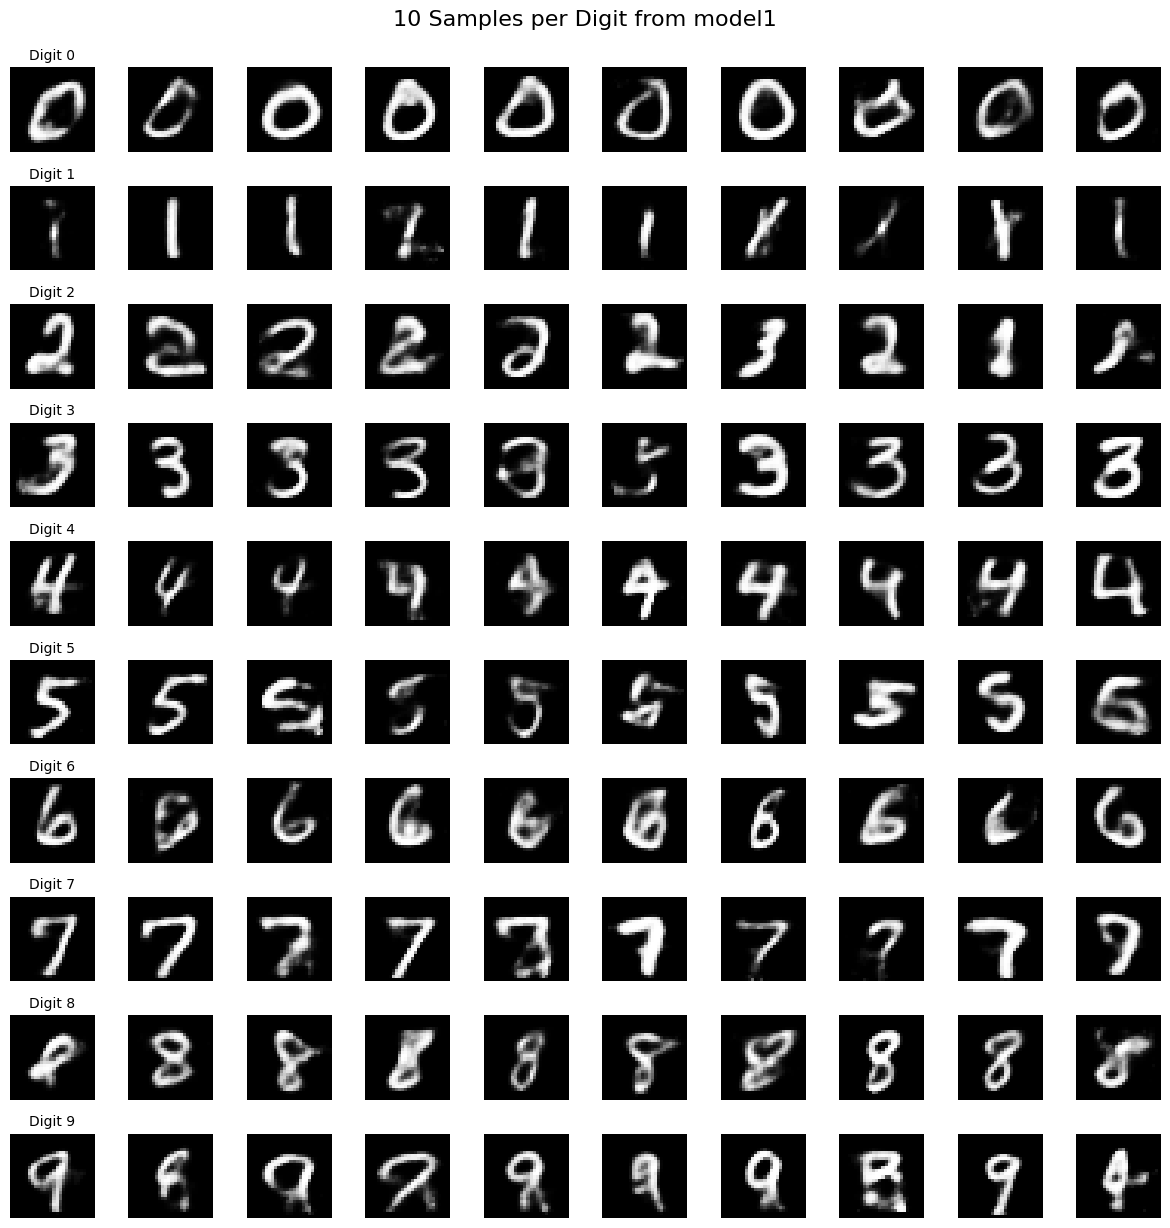

In [ ]:
import torch
import matplotlib.pyplot as plt

# Load synthetic data
synthetic = torch.load("data_saved/synthetic_mnist_cvae_60000_2.pt")
images = synthetic["images"]  # [N, 1, 28, 28]
labels = synthetic["labels"]  # [N]

# Ensure on CPU for plotting
images = images.cpu()
labels = labels.cpu()

# Plot 10 samples for each digit
fig, axes = plt.subplots(10, 10, figsize=(12, 12))

for digit in range(10):
    digit_indices = (labels == digit).nonzero(as_tuple=True)[0]
    selected_indices = digit_indices[:10]  # take first 10

    for i, idx in enumerate(selected_indices):
        ax = axes[digit, i]
        ax.imshow(images[idx].squeeze(), cmap="gray")
        ax.axis("off")
        if i == 0:
            ax.set_title(f"Digit {digit}", fontsize=10)

plt.tight_layout()
plt.suptitle("10 Samples per Digit from model1", y=1.02, fontsize=16)
plt.show()


/tmp/ipykernel_4165116/156800624.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  synthetic = torch.load("data_saved/synthetic_mnist_cvae_filtered_synthetic_model_generat

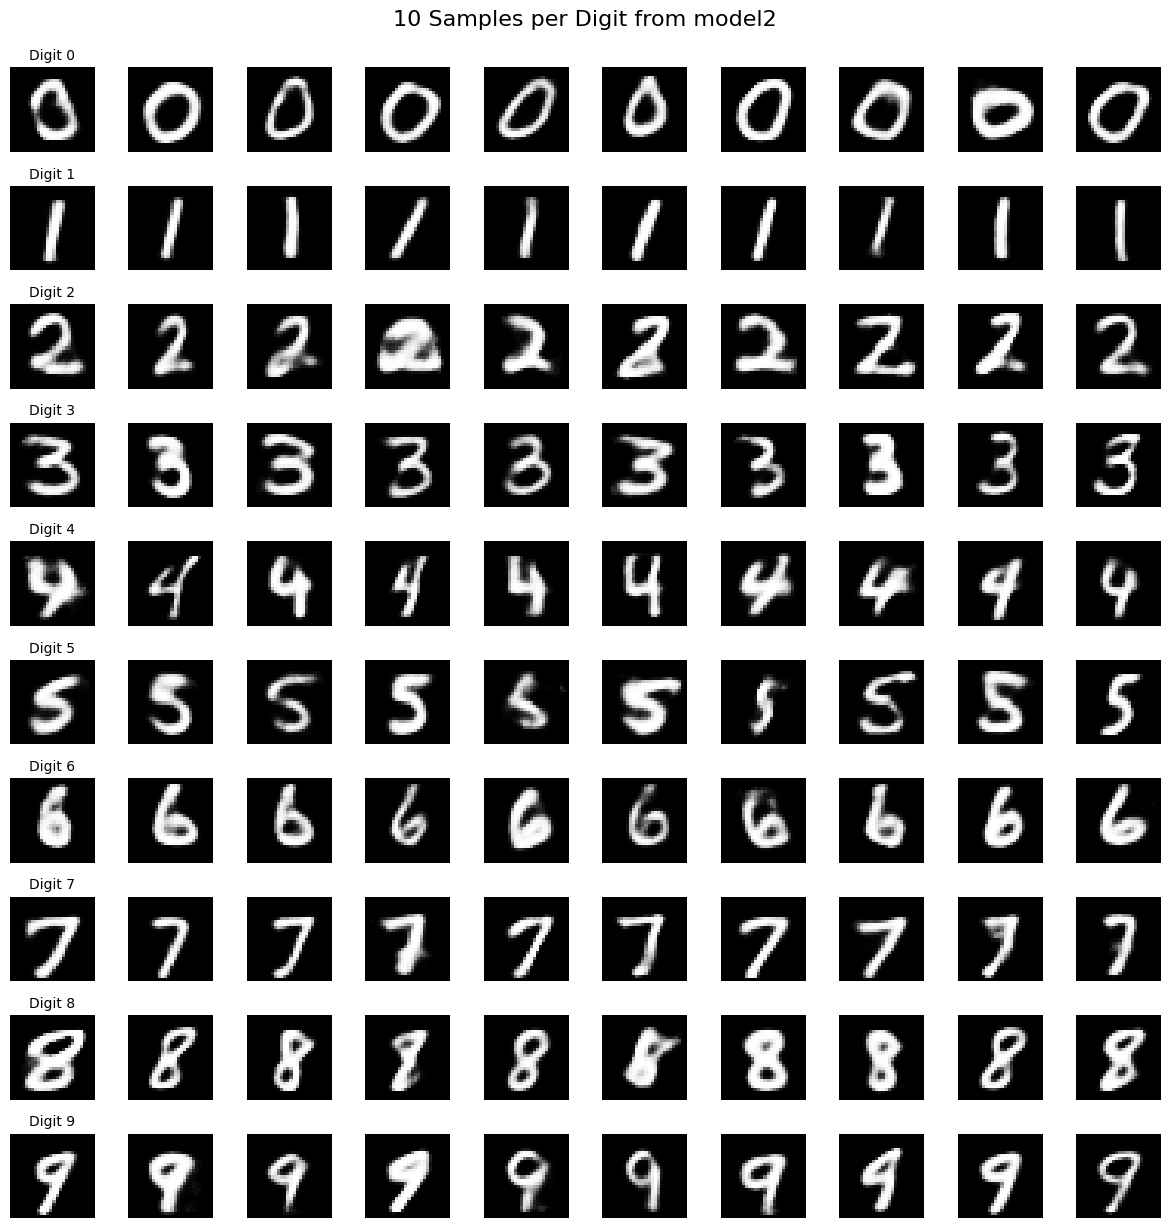

In [ ]:
import torch
import matplotlib.pyplot as plt

# Load synthetic data
synthetic = torch.load("data_saved/synthetic_mnist_cvae_filtered_synthetic_model_generated_data.pt")
images = synthetic["images"]  # [N, 1, 28, 28]
labels = synthetic["labels"]  # [N]

# Ensure on CPU for plotting
images = images.cpu()
labels = labels.cpu()

# Plot 10 samples for each digit
fig, axes = plt.subplots(10, 10, figsize=(12, 12))

for digit in range(10):
    digit_indices = (labels == digit).nonzero(as_tuple=True)[0]
    selected_indices = digit_indices[:10]  # take first 10

    for i, idx in enumerate(selected_indices):
        ax = axes[digit, i]
        ax.imshow(images[idx].squeeze(), cmap="gray")
        ax.axis("off")
        if i == 0:
            ax.set_title(f"Digit {digit}", fontsize=10)

plt.tight_layout()
plt.suptitle("10 Samples per Digit from model2", y=1.02, fontsize=16)
plt.show()


/tmp/ipykernel_4165116/1236427949.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  synthetic = torch.load("data_saved/synthetic_mnist_filtered_pgt05.pt")


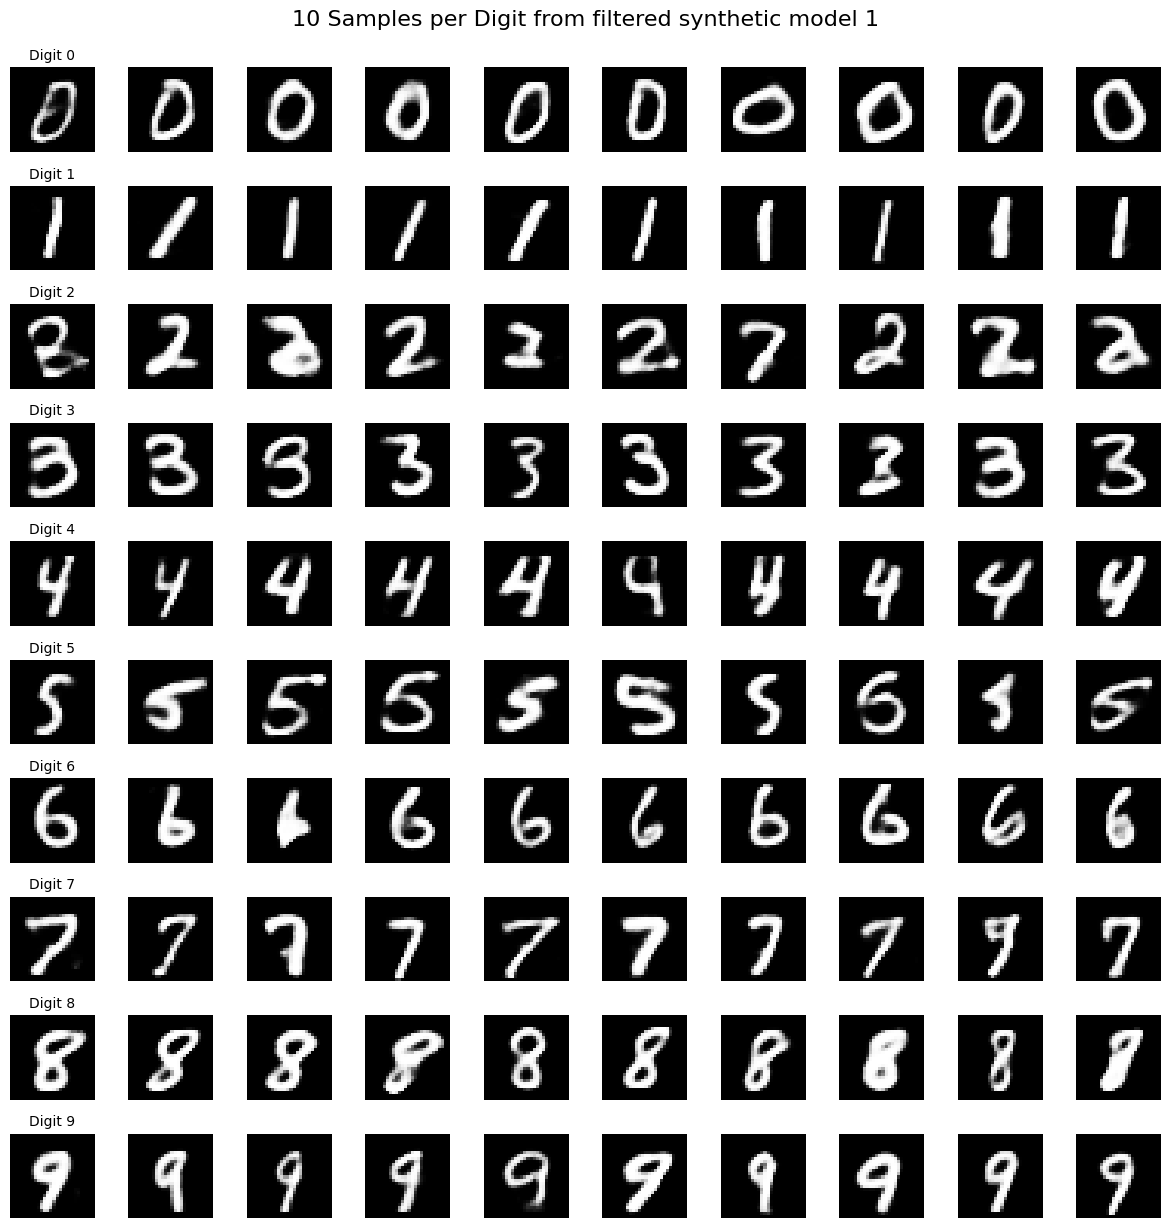

In [25]:
# load the filtered synthetic data
import torch
synthetic = torch.load("data_saved/synthetic_mnist_filtered_pgt05.pt")
images = synthetic["images"]  # [N, 1, 28, 28]
labels = synthetic["labels"]  # [N]

# Ensure on CPU for plotting
images = images.cpu()
labels = labels.cpu()

# Plot 10 samples for each digit
fig, axes = plt.subplots(10, 10, figsize=(12, 12))

for digit in range(10):
    digit_indices = (labels == digit).nonzero(as_tuple=True)[0]
    selected_indices = digit_indices[:10]  # take first 10

    for i, idx in enumerate(selected_indices):
        ax = axes[digit, i]
        ax.imshow(images[idx].squeeze(), cmap="gray")
        ax.axis("off")
        if i == 0:
            ax.set_title(f"Digit {digit}", fontsize=10)

plt.tight_layout()
plt.suptitle("10 Samples per Digit from filtered synthetic model 1", y=1.02, fontsize=16)
plt.show()


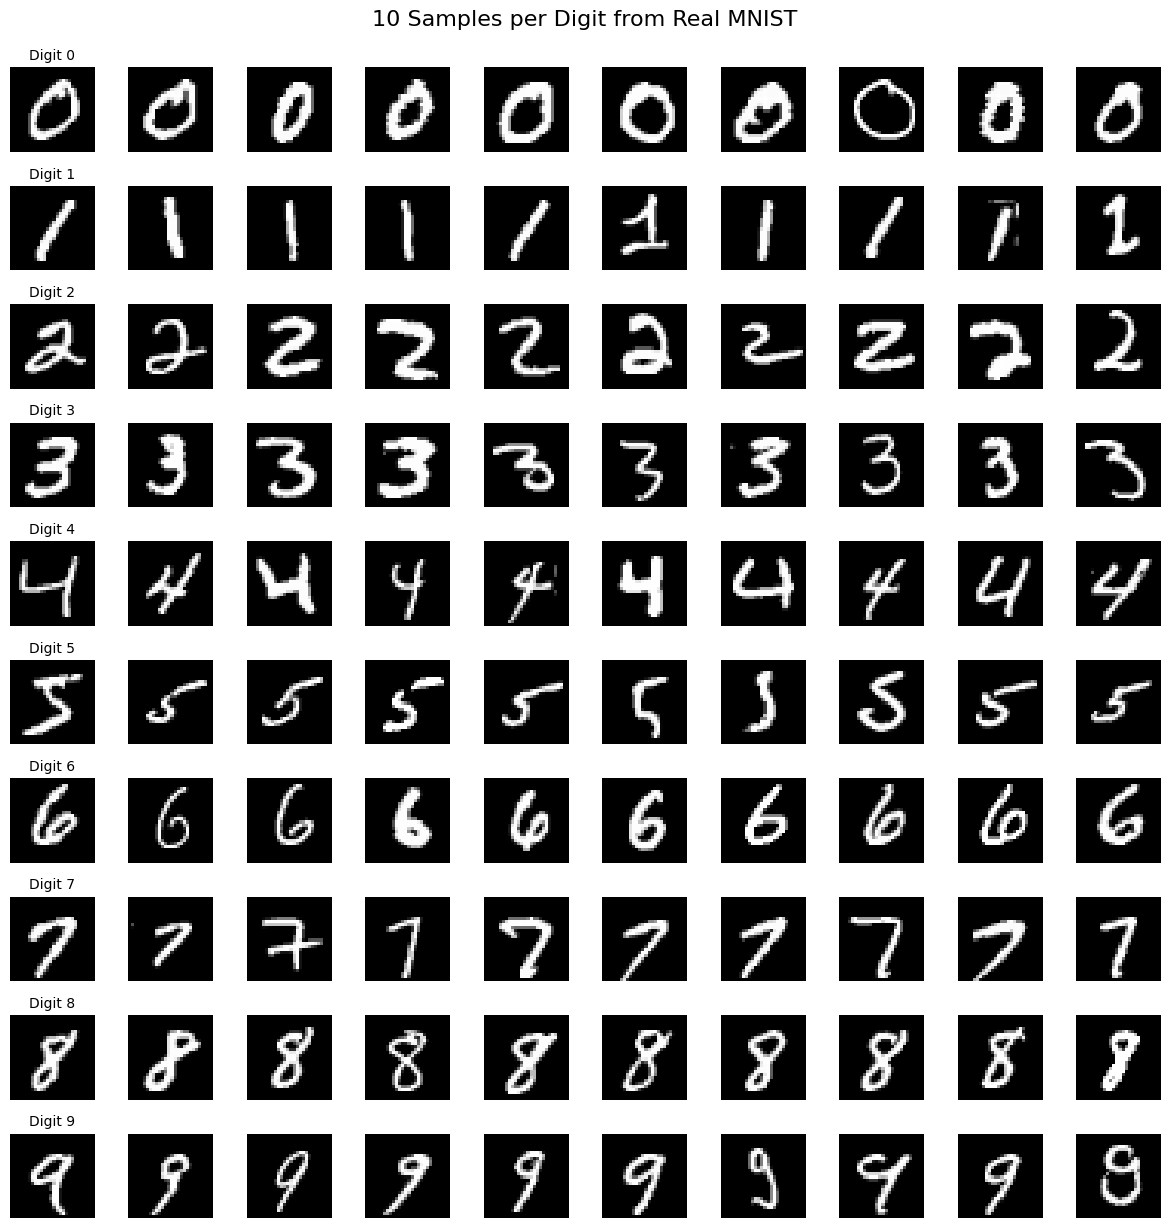

In [26]:
# real data
import torch
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
# Load real MNIST data
transform = transforms.ToTensor()
mnist_real = datasets.MNIST(root='./data', train=True, download=True, transform =transform)

# Plot 10 samples for each digit
fig, axes = plt.subplots(10, 10, figsize=(12, 12))
for digit in range(10):
    digit_indices = [i for i, (_, label) in enumerate(mnist_real) if label == digit]
    selected_indices = digit_indices[:10]  # take first 10

    for i, idx in enumerate(selected_indices):
        ax = axes[digit, i]
        ax.imshow(mnist_real[idx][0].squeeze(), cmap="gray")
        ax.axis("off")
        if i == 0:
            ax.set_title(f"Digit {digit}", fontsize=10)
plt.tight_layout()
plt.suptitle("10 Samples per Digit from Real MNIST", y=1.02, fontsize=16)
plt.show()

# Reconstruction Loss

In [34]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn.functional as F
from cvae_model import CVAE, cvae_loss
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Load model
model = CVAE(latent_dim=20, label_dim=10).to(device)
model.load_state_dict(torch.load("model_saved/cvae_mnist_10000.pth"))
model.eval()

# Load test set
test_dataset = datasets.MNIST(root="./data", train=False, transform=transforms.ToTensor())
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

# Evaluation
total_loss = 0
total_recon_loss = 0
total_kl = 0
num_samples = 0

with torch.no_grad():
    for x, y in test_loader:
        x = x.view(-1, 784).to(device)
        y = F.one_hot(y, num_classes=10).float().to(device)

        recon_x, mu, logvar = model(x, y)
        BCE = F.binary_cross_entropy(recon_x, x, reduction='sum')
        KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
        loss = BCE + KLD

        total_loss += loss.item()
        total_recon_loss += BCE.item()
        total_kl += KLD.item()
        num_samples += x.size(0)

print(f"Test Set Results:")
print(f"  Avg CVAE Loss: {total_loss / num_samples:.4f}")
print(f"  Avg Reconstruction (BCE) Loss: {total_recon_loss / num_samples:.4f}")
print(f"  Avg KL Divergence: {total_kl / num_samples:.4f}")


/tmp/ipykernel_3246439/2975022384.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("model_saved/cvae_mnist_10000.pth"))


Test Set Results:
  Avg CVAE Loss: 103.1223
  Avg Reconstruction (BCE) Loss: 80.6991
  Avg KL Divergence: 22.4232


In [35]:
# get the loss of synthetic model
import sys
sys.path.append("/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST")
import torch
from cvae_model import CVAE 
import os
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

latent_dim = 20
label_dim = 10
model = CVAE(latent_dim=latent_dim, label_dim=label_dim).to(device)
#os.chdir("/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST")  
os.chdir("/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST")
model.load_state_dict(torch.load("model_saved/cvae_mnist_filtered_synthetic_data_10000.pth"))
model.eval()


# Load test set
test_dataset = datasets.MNIST(root="./data", train=False, transform=transforms.ToTensor())
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

# Evaluation
total_loss = 0
total_recon_loss = 0
total_kl = 0
num_samples = 0

with torch.no_grad():
    for x, y in test_loader:
        x = x.view(-1, 784).to(device)
        y = F.one_hot(y, num_classes=10).float().to(device)

        recon_x, mu, logvar = model(x, y)
        BCE = F.binary_cross_entropy(recon_x, x, reduction='sum')
        KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
        loss = BCE + KLD

        total_loss += loss.item()
        total_recon_loss += BCE.item()
        total_kl += KLD.item()
        num_samples += x.size(0)

print(f"Test Set Results:")
print(f"  Avg CVAE Loss: {total_loss / num_samples:.4f}")
print(f"  Avg Reconstruction (BCE) Loss: {total_recon_loss / num_samples:.4f}")
print(f"  Avg KL Divergence: {total_kl / num_samples:.4f}")


/tmp/ipykernel_3246439/3783589042.py:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("model_saved/cvae_mnist_filtered_synthetic_data_10000

Test Set Results:
  Avg CVAE Loss: 110.7902
  Avg Reconstruction (BCE) Loss: 89.9765
  Avg KL Divergence: 20.8137


# full pipeline

In [1]:
import sys
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import os

sample_size = 5000
filter_threshold = 0.5

############################ real data training ############################
sys.path.append("/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST")

import torch.nn.functional as F
from cvae_model import CVAE, cvae_loss
from torch.utils.data import Subset

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [2]:
import sys
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import os

sample_size = 5000
filter_threshold = 0.5

############################ real data training ############################
sys.path.append("/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST")

import torch.nn.functional as F
from cvae_model import CVAE, cvae_loss
from torch.utils.data import Subset

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Hyperparameters
latent_dim = 20
label_dim = 10
batch_size = 128
epochs = 200
lr = 1e-3
# Load MNIST
transform = transforms.ToTensor()
full_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
train_dataset = Subset(full_dataset, range(sample_size))
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Initialize model
model = CVAE(latent_dim=latent_dim, label_dim=label_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

# One-hot encoding helper
def one_hot(labels, num_classes=10):
    return F.one_hot(labels, num_classes).float()

best_train_loss = float('inf')
patience = 5
trigger_times = 0

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for x, y in train_loader:
        x = x.view(-1, 784).to(device)
        y = one_hot(y).to(device)

        optimizer.zero_grad()
        recon_x, mu, logvar = model(x, y)
        loss = cvae_loss(recon_x, x, mu, logvar)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader.dataset)
    print(f"Epoch [{epoch+1}/{epochs}], Train Loss: {avg_loss:.4f}")

    # Early stopping based on training loss
    if avg_loss < best_train_loss:
        best_train_loss = avg_loss
        trigger_times = 0
    else:
        trigger_times += 1
        print(f"EarlyStopping counter: {trigger_times} out of {patience}")
        if trigger_times >= patience:
            print("Early stopping triggered.")
            break
os.chdir("/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST")  
# save the model to model_saved folder
torch.save(model.state_dict(), f"model_saved/cvae_mnist_{sample_size}.pth")
print(f"Model saved to model_saved/cvae_mnist_{sample_size}.pth")

############################ generate synthetic data ############################

model = CVAE(latent_dim=latent_dim, label_dim=label_dim)
model.load_state_dict(torch.load(f"model_saved/cvae_mnist_{sample_size}.pth"))
model.eval()

def generate_images_in_batches(model, total_samples, latent_dim, num_classes, batch_size=10000, device='cuda'):
    model.eval()
    generated_images = []
    all_labels = []

    for start in range(0, total_samples, batch_size):
        end = min(start + batch_size, total_samples)
        batch_size_actual = end - start

        # Generate z and y
        z = torch.randn(batch_size_actual, latent_dim).to(device)
        y = torch.arange(num_classes).repeat_interleave(total_samples // num_classes)[start:end]
        y_onehot = F.one_hot(y, num_classes=num_classes).float().to(device)

        with torch.no_grad():
            imgs = model.decode(z, y_onehot).view(-1, 1, 28, 28).cpu()
            generated_images.append(imgs)
            all_labels.append(y)

    images = torch.cat(generated_images, dim=0)
    labels = torch.cat(all_labels, dim=0)
    return images, labels

# large sample size for training
latent_dim = model.latent_dim
device = next(model.parameters()).device
gen_imgs_before_filter,y_before_filter = generate_images_in_batches(
    model=model,
    total_samples=6000000,
    latent_dim=latent_dim,
    num_classes=10,
    batch_size=10000,
    device=device
)

#save_path = f"data_saved/synthetic_mnist_cvae_{sample_size}.pt"
#torch.save({
#    'images': gen_imgs,    # Tensor [6000000, 1, 28, 28]
#    'labels': y            # Tensor [6000000]
#}, save_path)

# smaller sample size for evaluation
gen_imgs,y = generate_images_in_batches(
    model=model,
    total_samples=60000,
    latent_dim=latent_dim,
    num_classes=10,
    batch_size=10000,
    device=device
)

save_path = f"data_saved/synthetic_mnist_cvae_{sample_size}_2.pt"
torch.save({
    'images': gen_imgs,    # Tensor [60000, 1, 28, 28]
    'labels': y            # Tensor [60000]
}, save_path)

############################ filter synthetic data ############################

from discriminator import Discriminator
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
D = Discriminator().to(device)
D.load_state_dict(torch.load("model_saved/discriminator_mnist_cvae_2.pth"))
D.eval()

#data = torch.load(f"data_saved/synthetic_mnist_cvae_{sample_size}.pt")
#synthetic_images = data['images']  

synthetic_loader = DataLoader(gen_imgs_before_filter, batch_size=512)

all_probs = []

with torch.no_grad():
    for batch in synthetic_loader:
        batch = batch.to(device)
        probs = D(batch)  # [batch_size, 1], already sigmoid activated
        all_probs.append(probs.cpu())

all_probs = torch.cat(all_probs, dim=0)
# Flatten probs to shape [N]
probs = all_probs.squeeze(1)

# Load images and labels
images = gen_imgs_before_filter#data['images']      # [N, 1, 28, 28]
labels = y_before_filter #data['labels']      # [N]
# Create mask for p > filter_threshold
mask = probs > filter_threshold

# Apply mask
filtered_images = images[mask]
filtered_labels = labels[mask]

print(f"Selected {filtered_images.shape[0]} samples with p > {filter_threshold}")
# Save to file
torch.save({
    'images': filtered_images,
    'labels': filtered_labels
}, f"data_saved/synthetic_mnist_filtered_pgt{filter_threshold}_{sample_size}.pt")


############################ synthetic data retraining ############################

from torch.utils.data import TensorDataset

images = filtered_images  # shape: [N, 1, 28, 28]
labels = filtered_labels  # shape: [N]

print(f"Loaded {images.shape[0]} filtered synthetic samples")

# Preprocess: flatten images and convert labels to one-hot
images = images.view(-1, 784)  # flatten to [N, 784]

# Create dataset and dataloader
dataset = TensorDataset(images, labels)
train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# Initialize model
model = CVAE(latent_dim=latent_dim, label_dim=label_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

best_train_loss = float('inf')
for epoch in range(epochs):
    model.train()
    total_loss = 0

    for x, y in train_loader:
        x = x.view(-1, 784).to(device)
        y = one_hot(y).to(device)

        optimizer.zero_grad()
        recon_x, mu, logvar = model(x, y)
        loss = cvae_loss(recon_x, x, mu, logvar)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader.dataset)
    print(f"Epoch [{epoch+1}/{epochs}], Train Loss: {avg_loss:.4f}")

    # Early stopping based on training loss
    if avg_loss < best_train_loss:
        best_train_loss = avg_loss
        trigger_times = 0
    else:
        trigger_times += 1
        print(f"EarlyStopping counter: {trigger_times} out of {patience}")
        if trigger_times >= patience:
            print("Early stopping triggered.")
            break

# save the model to model_saved folder
torch.save(model.state_dict(), f"model_saved/cvae_mnist_filtered_synthetic_data_{sample_size}.pth")

# use the new model to generate synthetic data for evaluation
model.eval()

n_per_class = 6000
num_classes = 10
total_samples = n_per_class * num_classes
latent_dim = model.latent_dim
device = next(model.parameters()).device

z = torch.randn(total_samples, latent_dim).to(device)
y = torch.arange(num_classes).repeat_interleave(n_per_class)
y_onehot = F.one_hot(y, num_classes=num_classes).float().to(device)

with torch.no_grad():
    gen_imgs = model.decode(z, y_onehot).view(-1, 1, 28, 28).cpu()  # shape: [60000, 1, 28, 28]

# save the generated images and labels
save_path = f"data_saved/synthetic_mnist_cvae_filtered_synthetic_model_generated_data_{sample_size}.pt"
torch.save({"images": gen_imgs, "labels": y}, save_path)

############################ Model Evaluation ############################

# FID
from FID import calculate_fid_score

transform = transforms.ToTensor()

real_ds = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
### Synthetic dataset
synthetic = torch.load(f"data_saved/synthetic_mnist_cvae_{sample_size}_2.pt")
synthetic_ds = TensorDataset(synthetic['images'], torch.zeros(len(synthetic['images'])))
fid_value = calculate_fid_score(real_ds, synthetic_ds)
print(f"FID Score(real data and synthetic data): {fid_value:.2f}")

## filtered synthetic data
synthetic = torch.load(f"data_saved/synthetic_mnist_filtered_pgt{filter_threshold}_{sample_size}.pt")
synthetic_ds = TensorDataset(synthetic['images'], torch.zeros(len(synthetic['images'])))
fid_value = calculate_fid_score(real_ds, synthetic_ds)
print(f"FID Score(real data and filtered synthetic data): {fid_value:.2f}")

# Synthetic dataset
synthetic = torch.load(f"data_saved/synthetic_mnist_cvae_filtered_synthetic_model_generated_data_{sample_size}.pt")
synthetic_ds = TensorDataset(synthetic['images'], torch.zeros(len(synthetic['images'])))
fid_value = calculate_fid_score(real_ds, synthetic_ds)
print(f"FID Score(real data and model 2 synthetic data): {fid_value:.2f}")

# Reconstruction Loss

# Load model
model = CVAE(latent_dim=20, label_dim=10).to(device)
model.load_state_dict(torch.load(f"model_saved/cvae_mnist_{sample_size}.pth"))
model.eval()

# Load test set
test_dataset = datasets.MNIST(root="./data", train=False, transform=transforms.ToTensor())
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

# Evaluation
total_loss = 0
total_recon_loss = 0
total_kl = 0
num_samples = 0

with torch.no_grad():
    for x, y in test_loader:
        x = x.view(-1, 784).to(device)
        y = F.one_hot(y, num_classes=10).float().to(device)

        recon_x, mu, logvar = model(x, y)
        BCE = F.binary_cross_entropy(recon_x, x, reduction='sum')
        KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
        loss = BCE + KLD

        total_loss += loss.item()
        total_recon_loss += BCE.item()
        total_kl += KLD.item()
        num_samples += x.size(0)

print(f"Test Set Results(model1):")
print(f"  Avg CVAE Loss: {total_loss / num_samples:.4f}")
print(f"  Avg Reconstruction (BCE) Loss: {total_recon_loss / num_samples:.4f}")
print(f"  Avg KL Divergence: {total_kl / num_samples:.4f}")

# get the loss of synthetic model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CVAE(latent_dim=latent_dim, label_dim=label_dim).to(device)
model.load_state_dict(torch.load(f"model_saved/cvae_mnist_filtered_synthetic_data_{sample_size}.pth"))
model.eval()

# Load test set
test_dataset = datasets.MNIST(root="./data", train=False, transform=transforms.ToTensor())
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

# Evaluation
total_loss = 0
total_recon_loss = 0
total_kl = 0
num_samples = 0

with torch.no_grad():
    for x, y in test_loader:
        x = x.view(-1, 784).to(device)
        y = F.one_hot(y, num_classes=10).float().to(device)

        recon_x, mu, logvar = model(x, y)
        BCE = F.binary_cross_entropy(recon_x, x, reduction='sum')
        KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
        loss = BCE + KLD

        total_loss += loss.item()
        total_recon_loss += BCE.item()
        total_kl += KLD.item()
        num_samples += x.size(0)

print(f"Test Set Results(model2):")
print(f"  Avg CVAE Loss: {total_loss / num_samples:.4f}")
print(f"  Avg Reconstruction (BCE) Loss: {total_recon_loss / num_samples:.4f}")
print(f"  Avg KL Divergence: {total_kl / num_samples:.4f}")

Epoch [1/200], Train Loss: 288.0362
Epoch [2/200], Train Loss: 203.4514
Epoch [3/200], Train Loss: 178.1275
Epoch [4/200], Train Loss: 160.6898
Epoch [5/200], Train Loss: 151.9395
Epoch [6/200], Train Loss: 145.3641
Epoch [7/200], Train Loss: 140.0622
Epoch [8/200], Train Loss: 135.9289
Epoch [9/200], Train Loss: 132.6664
Epoch [10/200], Train Loss: 129.6968
Epoch [11/200], Train Loss: 127.2980
Epoch [12/200], Train Loss: 125.2455
Epoch [13/200], Train Loss: 123.0804
Epoch [14/200], Train Loss: 121.6151
Epoch [15/200], Train Loss: 120.1809
Epoch [16/200], Train Loss: 118.9090
Epoch [17/200], Train Loss: 117.7966
Epoch [18/200], Train Loss: 116.7419
Epoch [19/200], Train Loss: 115.8035
Epoch [20/200], Train Loss: 114.8102
Epoch [21/200], Train Loss: 114.2551
Epoch [22/200], Train Loss: 113.5655
Epoch [23/200], Train Loss: 112.8670
Epoch [24/200], Train Loss: 112.2706
Epoch [25/200], Train Loss: 111.7195
Epoch [26/200], Train Loss: 111.1590
Epoch [27/200], Train Loss: 110.5931
Epoch [28/

/tmp/ipykernel_3181123/3994269929.py:83: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"model_saved/cvae_mnist_{sample_size}.pth"))
/tmp/ip

Selected 92800 samples with p > 0.5
Loaded 92800 filtered synthetic samples
Epoch [1/200], Train Loss: 134.9682
Epoch [2/200], Train Loss: 103.8388
Epoch [3/200], Train Loss: 99.6962
Epoch [4/200], Train Loss: 97.9430
Epoch [5/200], Train Loss: 96.8849
Epoch [6/200], Train Loss: 96.2541
Epoch [7/200], Train Loss: 95.7802
Epoch [8/200], Train Loss: 95.4346
Epoch [9/200], Train Loss: 95.1482
Epoch [10/200], Train Loss: 94.9218
Epoch [11/200], Train Loss: 94.7406
Epoch [12/200], Train Loss: 94.5847
Epoch [13/200], Train Loss: 94.4982
Epoch [14/200], Train Loss: 94.3867
Epoch [15/200], Train Loss: 94.2774
Epoch [16/200], Train Loss: 94.1711
Epoch [17/200], Train Loss: 94.1286
Epoch [18/200], Train Loss: 94.0474
Epoch [19/200], Train Loss: 93.9837
Epoch [20/200], Train Loss: 93.9318
Epoch [21/200], Train Loss: 93.8989
Epoch [22/200], Train Loss: 93.8216
Epoch [23/200], Train Loss: 93.7775
Epoch [24/200], Train Loss: 93.7145
Epoch [25/200], Train Loss: 93.7013
Epoch [26/200], Train Loss: 93.

/tmp/ipykernel_3181123/3994269929.py:269: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  synthetic = torch.load(f"data_saved/synthetic_mnist_cvae_{sample_size}_2.pt")
Extract

FID Score(real data and synthetic data): 0.04


...

FID Score(real data and model 2 synthetic data): 0.04


/tmp/ipykernel_3181123/3994269929.py:290: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"model_saved/cvae_mnist_{sample_size}.pth"))


Test Set Results(model1):
  Avg CVAE Loss: 107.1544
  Avg Reconstruction (BCE) Loss: 84.3508
  Avg KL Divergence: 22.8036


/tmp/ipykernel_3181123/3994269929.py:327: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"model_saved/cvae_mnist_filtered_synthetic_data_{sa

Test Set Results(model2):
  Avg CVAE Loss: 109.9169
  Avg Reconstruction (BCE) Loss: 88.2359
  Avg KL Divergence: 21.6810


In [2]:
import os
import torch
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms
from torchvision.transforms.functional import resize
from torchmetrics.image.fid import FrechetInceptionDistance

# -------------------------------------------------
# 1.  A *drop-in* function to compute FID
# -------------------------------------------------
@torch.no_grad()
def calculate_fid_score(real_ds, synth_ds, batch_size: int = 256) -> float:
    """
    FID(real_ds, synth_ds) – works for 1- or 3-channel tensors in [0,1] or uint8.
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    fid = FrechetInceptionDistance(feature=2048, normalize=True).to(device)

    def preprocess(batch: torch.Tensor) -> torch.Tensor:
        """
        Make (N,3,299,299) uint8 as required by torch-fidelity's Inception-v3.
        """
        if batch.dim() == 3:                               # (C,H,W) or (H,W,C)
            batch = batch.unsqueeze(0)                     # -> (1,C,H,W) / (1,H,W,C)

        if batch.dim() == 4 and batch.shape[1] not in {1, 3}:
            batch = batch.permute(0, 3, 1, 2)              # channel-last -> channel-first

        if batch.shape[1] == 1:                            # grayscale -> RGB
            batch = batch.repeat(1, 3, 1, 1)

        batch = resize(batch.float(), [299, 299], antialias=True)  # 299×299, float

        if batch.max() <= 1.0:                             # [0,1] -> [0,255] uint8
            batch = (batch * 255).clamp(0, 255)
        return batch.to(torch.uint8)

    for loader, is_real in [
        (DataLoader(real_ds,   batch_size=batch_size, shuffle=False), True),
        (DataLoader(synth_ds,  batch_size=batch_size, shuffle=False), False),
    ]:
        for batch in loader:
            imgs = batch[0] if isinstance(batch, (list, tuple)) else batch
            fid.update(preprocess(imgs).to(device), real=is_real)

    score = float(fid.compute())
    fid.reset()
    return score

# -------------------------------------------------
# 2.  Prepare the real MNIST test set  (grayscale -> tensor [0,1])
# -------------------------------------------------
transform = transforms.ToTensor()                 # yields (1,28,28) float32
real_ds = datasets.MNIST(root="./data",           # download if not present
                         train=False,
                         transform=transform,
                         download=True)

# -------------------------------------------------
# 3.  Load the synthetic images that you saved earlier
# -------------------------------------------------
sample_size = 5000                                # change if you like
os.chdir("/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST")

synthetic = torch.load(f"data_saved/synthetic_mnist_cvae_{sample_size}_2.pt")
images = synthetic["images"]                      # shape (N,1,28,28) *or* (N,28,28)

# if they are (N,28,28) add the missing channel dim
if images.dim() == 3:                             # (N,H,W)
    images = images.unsqueeze(1)                  # -> (N,1,H,W)

synthetic_ds = TensorDataset(images,
                             torch.zeros(len(images), dtype=torch.long))

# -------------------------------------------------
# 4.  Compute FID
# -------------------------------------------------
fid_value = calculate_fid_score(real_ds, synthetic_ds)
print(f"FID(real ↔ synthetic): {fid_value:.2f}")


/tmp/ipykernel_1015747/1392485422.py:65: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  synthetic = torch.load(f"data_saved/synthetic_mnist_cvae_{sample_size}_2.pt")


FID(real ↔ synthetic): 142.51


In [ ]:
synthetic = torch.load(f"data_saved/synthetic_mnist_cvae_filtered_synthetic_model_generated_data_{sample_size}.pt")
images = synthetic["images"]            
synthetic_ds = TensorDataset(images,torch.zeros(len(images), dtype=torch.long))
fid_value = calculate_fid_score(real_ds, synthetic_ds)
print(f"FID(real ↔ synthetic): {fid_value:.2f}")

/tmp/ipykernel_1015747/3995938234.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  synthetic = torch.load(f"data_saved/synthetic_mnist_cvae_filtered_synthetic_model_gener

FID(real ↔ synthetic): 138.75


In [9]:
## filtered synthetic data
synthetic = torch.load(f"data_saved/synthetic_mnist_filtered_pgt{filter_threshold}_{sample_size}.pt")
synthetic_ds = TensorDataset(synthetic['images'], torch.zeros(len(synthetic['images'])))
fid_value = calculate_fid_score(real_ds, synthetic_ds)
print(f"FID(real ↔ synthetic): {fid_value:.2f}")

/tmp/ipykernel_1015747/3628675243.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  synthetic = torch.load(f"data_saved/synthetic_mnist_filtered_pgt{filter_threshold}_{sam

FID(real ↔ synthetic): 89.17


In [10]:
import torch
import numpy as np
from torch.utils.data import Subset

# --------------- 1. 随机拆分 real_ds ----------------
rng  = np.random.default_rng(seed=42)          # 可换成 torch.Generator 手动设 seed
idxs = rng.permutation(len(real_ds))
half = len(idxs) // 2

real_ds_A = Subset(real_ds, idxs[:half])       # 第一半
real_ds_B = Subset(real_ds, idxs[half:])       # 第二半

# --------------- 2. 计算基准 FID --------------------
fid_real_real = calculate_fid_score(real_ds_A, real_ds_B)
print(f"Sanity-check FID (real ↔ real): {fid_real_real:.2f}")


Sanity-check FID (real ↔ real): 2.98


In [4]:
synthetic = torch.load(f"data_saved/synthetic_mnist_cvae_filtered_synthetic_model_generated_data_{sample_size}.pt")
images = synthetic["images"]                      # shape (N,1,28,28) *or* (N,28,28)

# if they are (N,28,28) add the missing channel dim
if images.dim() == 3:                             # (N,H,W)
    images = images.unsqueeze(1)                  # -> (N,1,H,W)

synthetic_ds = TensorDataset(images,
                             torch.zeros(len(images), dtype=torch.long))

# -------------------------------------------------
# 4.  Compute FID
# -------------------------------------------------
fid_value = calculate_fid_score(real_ds, real_ds)
print(f"FID(real ↔ synthetic): {fid_value:.2f}")

/tmp/ipykernel_1015747/1790529855.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  synthetic = torch.load(f"data_saved/synthetic_mnist_cvae_filtered_synthetic_model_gener

FID(real ↔ synthetic): -0.00


In [ ]:
transform = transforms.ToTensor()

real_ds = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
### Synthetic dataset
synthetic = torch.load(f"data_saved/synthetic_mnist_cvae_{sample_size}_2.pt")
synthetic_ds = TensorDataset(synthetic['images'], torch.zeros(len(synthetic['images'])))
fid_value = calculate_fid_score(real_ds, synthetic_ds)
print(f"FID Score(real data and synthetic data): {fid_value:.2f}")

## filtered synthetic data
synthetic = torch.load(f"data_saved/synthetic_mnist_filtered_pgt{filter_threshold}_{sample_size}.pt")
synthetic_ds = TensorDataset(synthetic['images'], torch.zeros(len(synthetic['images'])))
fid_value = calculate_fid_score(real_ds, synthetic_ds)
print(f"FID Score(real data and filtered synthetic data): {fid_value:.2f}")

# Synthetic dataset
synthetic = torch.load(f"data_saved/synthetic_mnist_cvae_filtered_synthetic_model_generated_data_{sample_size}.pt")
synthetic_ds = TensorDataset(synthetic['images'], torch.zeros(len(synthetic['images'])))
fid_value = calculate_fid_score(real_ds, synthetic_ds)
print(f"FID Score(real data and model 2 synthetic data): {fid_value:.2f}")

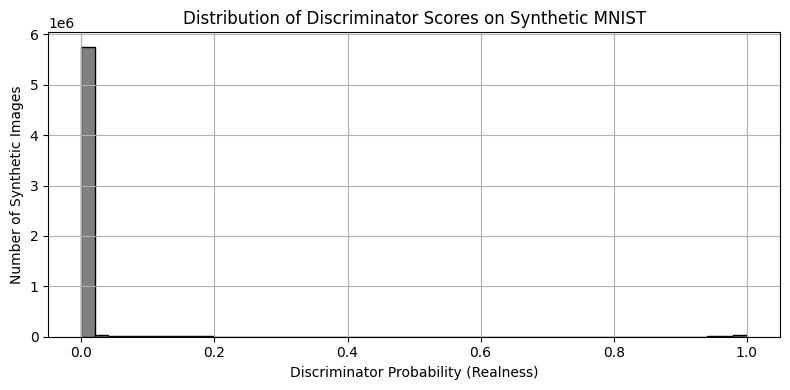

In [3]:
import torch
import matplotlib.pyplot as plt
os.chdir("/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST")
#probs = torch.load("data_saved/synthetic_mnist_cvae_probs_2.pt")  # shape: [60000, 1]
#probs = all_probs#probs.squeeze().numpy()  # shape: [60000]
#probs = probs.squeeze().numpy()  # shape: [60000]
plt.figure(figsize=(8, 4))
plt.hist(probs, bins=50, color='gray', edgecolor='black')
plt.xlabel("Discriminator Probability (Realness)")
plt.ylabel("Number of Synthetic Images")
plt.title("Distribution of Discriminator Scores on Synthetic MNIST")
plt.grid(True)
plt.tight_layout()
plt.show()


/tmp/ipykernel_3181123/2138600691.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  synthetic = torch.load(f"data_saved/synthetic_mnist_cvae_{sample_size}_2.pt")


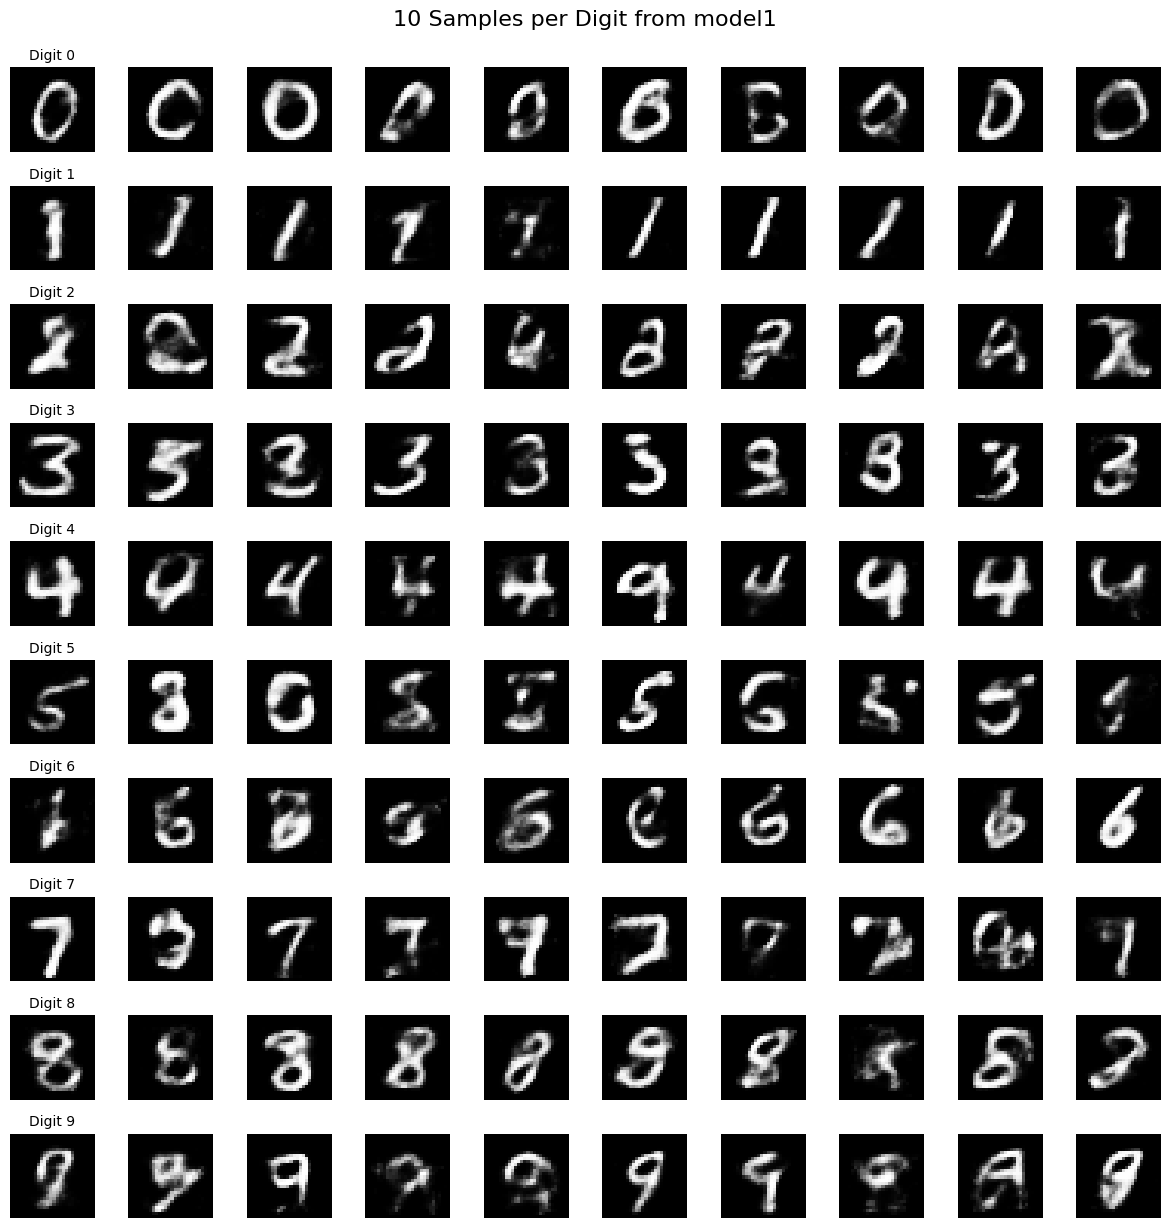

In [4]:
# synthetic data from model 1
import torch
import matplotlib.pyplot as plt

# Load synthetic data
synthetic = torch.load(f"data_saved/synthetic_mnist_cvae_{sample_size}_2.pt")
images = synthetic["images"]  # [N, 1, 28, 28]
labels = synthetic["labels"]  # [N]

# Ensure on CPU for plotting
images = images.cpu()
labels = labels.cpu()

# Plot 10 samples for each digit
fig, axes = plt.subplots(10, 10, figsize=(12, 12))

for digit in range(10):
    digit_indices = (labels == digit).nonzero(as_tuple=True)[0]
    selected_indices = digit_indices[:10]  # take first 10

    for i, idx in enumerate(selected_indices):
        ax = axes[digit, i]
        ax.imshow(images[idx].squeeze(), cmap="gray")
        ax.axis("off")
        if i == 0:
            ax.set_title(f"Digit {digit}", fontsize=10)

plt.tight_layout()
plt.suptitle("10 Samples per Digit from model1", y=1.02, fontsize=16)
plt.show()


/tmp/ipykernel_3181123/3604630113.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  synthetic = torch.load(f"data_saved/synthetic_mnist_filtered_pgt{filter_threshold}_{sam

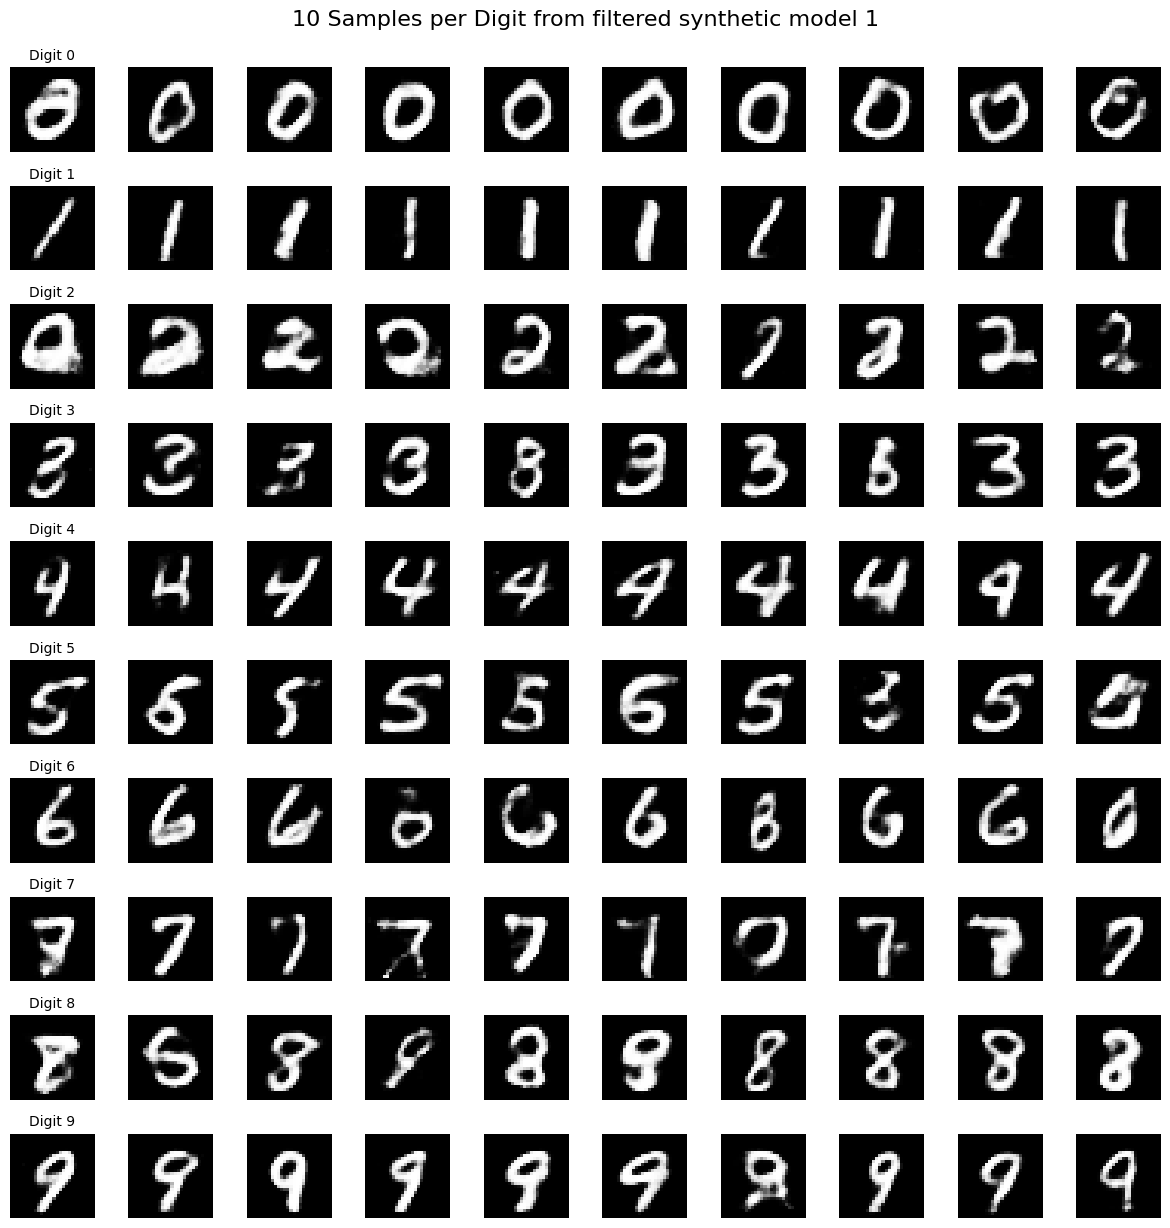

In [5]:
# filtered synthetic data

# load the filtered synthetic data
import torch
synthetic = torch.load(f"data_saved/synthetic_mnist_filtered_pgt{filter_threshold}_{sample_size}.pt")
images = synthetic["images"]  # [N, 1, 28, 28]
labels = synthetic["labels"]  # [N]

# Ensure on CPU for plotting
images = images.cpu()
labels = labels.cpu()

# Plot 10 samples for each digit
fig, axes = plt.subplots(10, 10, figsize=(12, 12))

for digit in range(10):
    digit_indices = (labels == digit).nonzero(as_tuple=True)[0]
    selected_indices = digit_indices[:10]  # take first 10

    for i, idx in enumerate(selected_indices):
        ax = axes[digit, i]
        ax.imshow(images[idx].squeeze(), cmap="gray")
        ax.axis("off")
        if i == 0:
            ax.set_title(f"Digit {digit}", fontsize=10)

plt.tight_layout()
plt.suptitle("10 Samples per Digit from filtered synthetic model 1", y=1.02, fontsize=16)
plt.show()


/tmp/ipykernel_3181123/2313906091.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  synthetic = torch.load(f"data_saved/synthetic_mnist_cvae_filtered_synthetic_model_gener

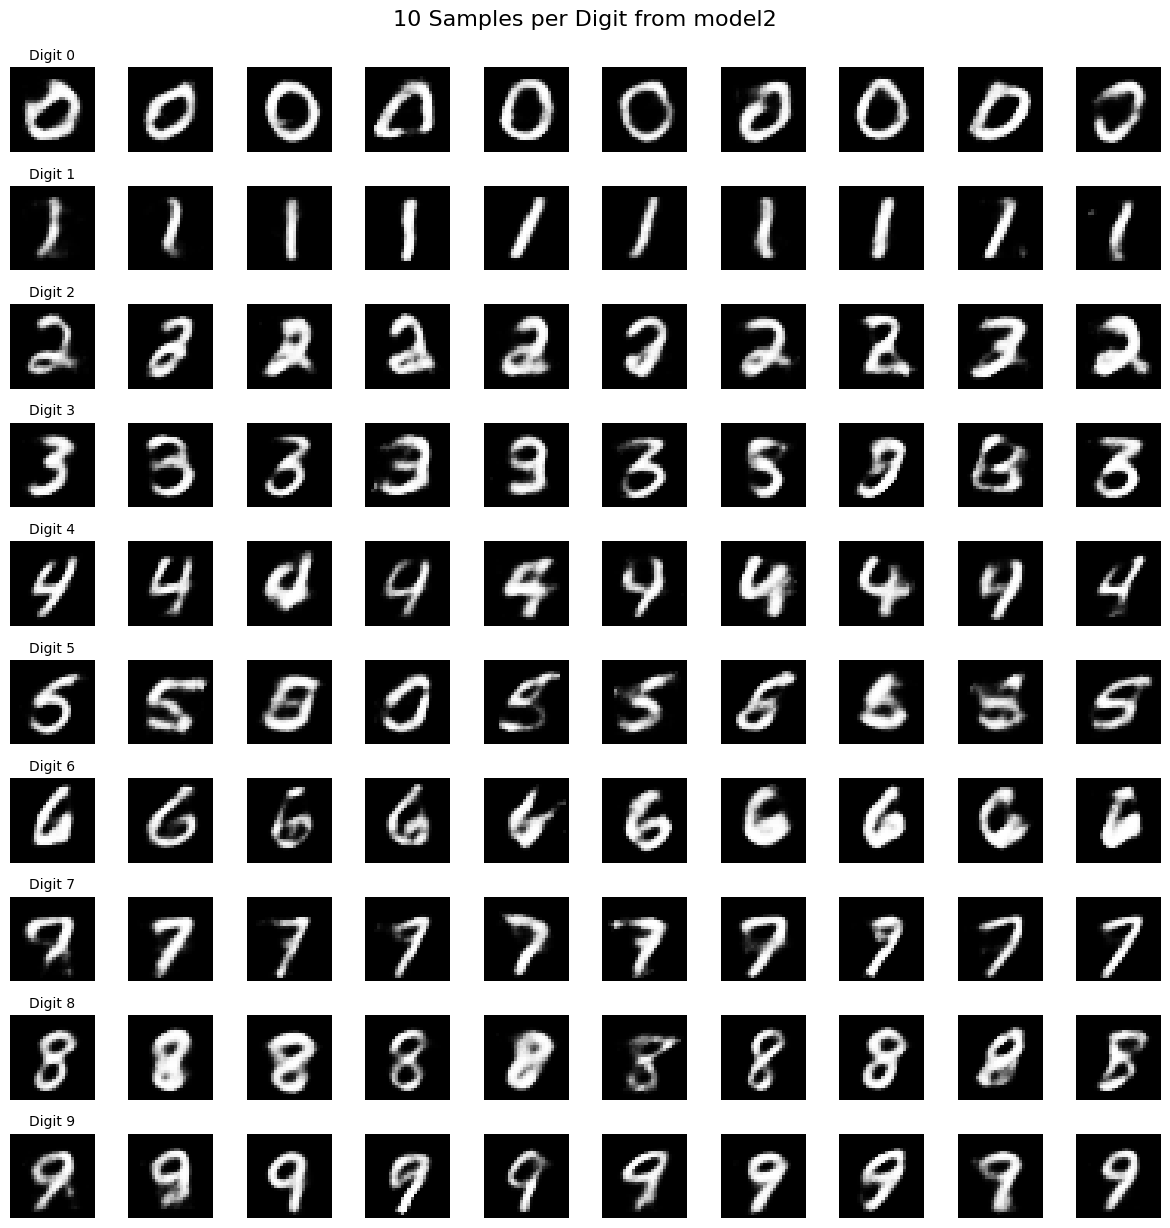

In [6]:
# synthetic data from model 2

import torch
import matplotlib.pyplot as plt

# Load synthetic data
synthetic = torch.load(f"data_saved/synthetic_mnist_cvae_filtered_synthetic_model_generated_data_{sample_size}.pt")
images = synthetic["images"]  # [N, 1, 28, 28]
labels = synthetic["labels"]  # [N]

# Ensure on CPU for plotting
images = images.cpu()
labels = labels.cpu()

# Plot 10 samples for each digit
fig, axes = plt.subplots(10, 10, figsize=(12, 12))

for digit in range(10):
    digit_indices = (labels == digit).nonzero(as_tuple=True)[0]
    selected_indices = digit_indices[:10]  # take first 10

    for i, idx in enumerate(selected_indices):
        ax = axes[digit, i]
        ax.imshow(images[idx].squeeze(), cmap="gray")
        ax.axis("off")
        if i == 0:
            ax.set_title(f"Digit {digit}", fontsize=10)

plt.tight_layout()
plt.suptitle("10 Samples per Digit from model2", y=1.02, fontsize=16)
plt.show()



# another CVAE